# Esperimento 1 — Tassonomia Emergente

**Domanda di ricerca**: I cluster che emergono dagli embedding di termini giuridici tecnici corrispondono ai rami del diritto?

## Quadro matematico

Un **embedding** e' una funzione deterministica che mappa un'unita' linguistica in un vettore a dimensionalita' fissa:

$$f: \text{testo} \to \mathbb{R}^n$$

dove $n$ e' il numero di dimensioni (tipicamente 384-4096). La funzione e' **deterministica**: lo stesso input produce sempre lo stesso vettore. Nessuna componente stocastica.

L'idea fondamentale e' che la **prossimita' semantica** tra concetti si traduce in **prossimita' geometrica** tra i rispettivi vettori. Due termini giuridici appartenenti allo stesso ramo del diritto dovrebbero occupare posizioni vicine nello spazio vettoriale — formando **cluster** riconoscibili.

## Ipotesi

- **H₀** (nulla): La distribuzione nello spazio degli embedding di termini giuridici e' indipendente dalla loro appartenenza ai rami del diritto. I cluster ottenuti tramite partizionamento automatico non correlano con la classificazione dottrinale.
- **H₁** (alternativa): I termini giuridici appartenenti allo stesso ramo del diritto occupano regioni prossime nello spazio degli embedding, producendo cluster che corrispondono significativamente alla tassonomia giuridica consolidata.

## Fondamento giuridico

La tassonomia del diritto in rami (penale, civile, amministrativo, costituzionale, processuale, internazionale) non e' una convenzione arbitraria. Riflette differenze strutturali reali:
- **Diversita' di oggetto**: il penale tutela beni giuridici contro aggressioni; il civile regola rapporti patrimoniali tra privati
- **Diversita' di linguaggio**: ogni ramo ha un lessico tecnico evolutosi con secoli di dottrina e giurisprudenza
- **Diversita' di principi**: legalita' (penale), autonomia privata (civile), legalita'-imparzialita' (amministrativo)

**Obiezione metodologica** (da controllare): i rami non sono compartimenti stagni. Esistono termini trasversali ("responsabilita'", "sanzione"), zone di confine (illecito civile vs penale), e istituti a doppia collocazione ("danno" e' sia civile che penale).

## Riferimenti
- Mikolov et al. (2013) — Distributed Representations of Words: la prossimita' semantica e' catturata come prossimita' geometrica
- Kriegeskorte et al. (2008) — Representational Similarity Analysis: metodo per confrontare strutture rappresentazionali
- Kozlowski et al. (2019) — Geometry of Culture: strutture sociali emergono dalla geometria degli embedding
- Chalkidis et al. (2020) — Legal-BERT: embedding specializzati migliorano la rappresentazione giuridica

## Protocollo
1. Selezionare ~300 termini giuridici italiani, annotati per ramo del diritto (6 rami, livello 1) e sotto-ramo (livello 2)
2. Estrarre embedding con almeno 2 modelli di diversa natura e dimensione
3. Clustering: K-means (k=6), gerarchico (Ward), HDBSCAN (k automatico)
4. Metriche: ARI, NMI, V-measure, Silhouette
5. Test di permutazione (10.000 permutazioni) per significativita' dell'ARI
6. Analisi dei confound: frequenza, lunghezza token, co-occorrenza
7. Validazione giuridica degli errori di classificazione

In [23]:
# == Configurazione ambiente ======================================
# Esperimento 1: Tassonomia Emergente
# Progetto "Norme come Oggetti Geometrici"

%matplotlib inline

import json
import gc
import logging
import warnings
from pathlib import Path
from collections import Counter, defaultdict
from dataclasses import dataclass, field
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.spatial.distance import cosine, pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    v_measure_score,
    silhouette_score,
    confusion_matrix,
)
from sklearn.preprocessing import normalize

# Opzionale: HDBSCAN
try:
    import hdbscan
    HAS_HDBSCAN = True
except ImportError:
    HAS_HDBSCAN = False
    print("hdbscan non installato. Installare con: pip install hdbscan")

# Opzionale: UMAP per visualizzazione 2D
try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("umap-learn non installato. Installare con: pip install umap-learn")

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*n_jobs.*")

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger("exp01")

# Palette Okabe-Ito (colorblind-safe) — un colore per ramo
PALETTE = {
    "penale": "#E69F00",
    "civile": "#56B4E9",
    "amministrativo": "#009E73",
    "costituzionale": "#F0E442",
    "processuale": "#0072B2",
    "internazionale": "#D55E00",
    "trasversale": "#CC79A7",
}
sns.set_theme(style="whitegrid", font_scale=1.1)

SEED = 42
np.random.seed(SEED)

print("Ambiente configurato.")
print(f"  HDBSCAN: {'disponibile' if HAS_HDBSCAN else 'non disponibile'}")
print(f"  UMAP: {'disponibile' if HAS_UMAP else 'non disponibile'}")

Ambiente configurato.
  HDBSCAN: disponibile
  UMAP: disponibile


## Sezione 1: Lessico Giuridico

Selezione di ~300 termini giuridici tecnici italiani, classificati per ramo del diritto.

### Criteri di selezione
- **Fonte**: indici analitici del Codice Civile, Codice Penale, Codice di Procedura Civile e Penale, Costituzione, e manuali di riferimento (Mantovani, Torrente-Schlesinger, Casetta, Bin-Pitruzzella, Mandrioli, Conforti)
- **Bilanciamento**: ~50 termini per ramo (6 rami = ~300 termini)
- **Tecnicita'**: privilegiati termini esclusivamente o prevalentemente giuridici
- **Livello 1** (6 classi): penale, civile, amministrativo, costituzionale, processuale, internazionale
- **Livello 2** (sotto-rami): parte generale/speciale, obbligazioni/reali/famiglia, sostanziale/processuale, ecc.
- **Flag "trasversale"**: termini che appartengono a piu' rami (non esclusi ma annotati)

### Nota metodologica
La selezione e' documentata e riproducibile. I termini trasversali sono inclusi intenzionalmente come controllo interno: se il clustering li assegna coerentemente a un ramo dominante o li isola, cio' e' informativo.

In [24]:
# == Lessico giuridico italiano annotato ===========================
# Ogni termine ha: testo italiano, ramo (livello 1), sotto-ramo (livello 2),
# flag trasversale.
#
# ~50 termini per ramo x 6 rami = ~300 termini.
# Fonti: indici analitici dei codici + manuali di riferimento.

LESSICO = [
    # =================================================================
    # DIRITTO PENALE (~50 termini)
    # Fonte: Codice Penale, Mantovani, Fiandaca-Musco
    # =================================================================

    # -- Parte Generale: teoria del reato --
    {"termine": "reato", "ramo": "penale", "sotto_ramo": "parte_generale", "trasversale": False},
    {"termine": "delitto", "ramo": "penale", "sotto_ramo": "parte_generale", "trasversale": False},
    {"termine": "contravvenzione", "ramo": "penale", "sotto_ramo": "parte_generale", "trasversale": False},
    {"termine": "dolo", "ramo": "penale", "sotto_ramo": "parte_generale", "trasversale": False},
    {"termine": "colpa", "ramo": "penale", "sotto_ramo": "parte_generale", "trasversale": False},
    {"termine": "preterintenzione", "ramo": "penale", "sotto_ramo": "parte_generale", "trasversale": False},
    {"termine": "antigiuridicita'", "ramo": "penale", "sotto_ramo": "parte_generale", "trasversale": False},
    {"termine": "imputabilita'", "ramo": "penale", "sotto_ramo": "parte_generale", "trasversale": False},
    {"termine": "tipicita'", "ramo": "penale", "sotto_ramo": "parte_generale", "trasversale": False},
    {"termine": "colpevolezza", "ramo": "penale", "sotto_ramo": "parte_generale", "trasversale": False},
    {"termine": "punibilita'", "ramo": "penale", "sotto_ramo": "parte_generale", "trasversale": False},
    {"termine": "tentativo", "ramo": "penale", "sotto_ramo": "parte_generale", "trasversale": False},
    {"termine": "concorso di persone nel reato", "ramo": "penale", "sotto_ramo": "parte_generale", "trasversale": False},
    {"termine": "concorso di reati", "ramo": "penale", "sotto_ramo": "parte_generale", "trasversale": False},
    {"termine": "recidiva", "ramo": "penale", "sotto_ramo": "parte_generale", "trasversale": False},
    {"termine": "legittima difesa", "ramo": "penale", "sotto_ramo": "parte_generale", "trasversale": False},
    {"termine": "stato di necessita'", "ramo": "penale", "sotto_ramo": "parte_generale", "trasversale": True},
    {"termine": "nesso causale", "ramo": "penale", "sotto_ramo": "parte_generale", "trasversale": True},
    {"termine": "circostanze aggravanti", "ramo": "penale", "sotto_ramo": "parte_generale", "trasversale": False},
    {"termine": "circostanze attenuanti", "ramo": "penale", "sotto_ramo": "parte_generale", "trasversale": False},

    # -- Parte Speciale: reati specifici --
    {"termine": "omicidio", "ramo": "penale", "sotto_ramo": "parte_speciale", "trasversale": False},
    {"termine": "furto", "ramo": "penale", "sotto_ramo": "parte_speciale", "trasversale": False},
    {"termine": "rapina", "ramo": "penale", "sotto_ramo": "parte_speciale", "trasversale": False},
    {"termine": "estorsione", "ramo": "penale", "sotto_ramo": "parte_speciale", "trasversale": False},
    {"termine": "truffa", "ramo": "penale", "sotto_ramo": "parte_speciale", "trasversale": False},
    {"termine": "peculato", "ramo": "penale", "sotto_ramo": "parte_speciale", "trasversale": False},
    {"termine": "corruzione", "ramo": "penale", "sotto_ramo": "parte_speciale", "trasversale": False},
    {"termine": "concussione", "ramo": "penale", "sotto_ramo": "parte_speciale", "trasversale": False},
    {"termine": "diffamazione", "ramo": "penale", "sotto_ramo": "parte_speciale", "trasversale": False},
    {"termine": "calunnia", "ramo": "penale", "sotto_ramo": "parte_speciale", "trasversale": False},
    {"termine": "falso ideologico", "ramo": "penale", "sotto_ramo": "parte_speciale", "trasversale": False},
    {"termine": "falso materiale", "ramo": "penale", "sotto_ramo": "parte_speciale", "trasversale": False},
    {"termine": "ricettazione", "ramo": "penale", "sotto_ramo": "parte_speciale", "trasversale": False},
    {"termine": "riciclaggio", "ramo": "penale", "sotto_ramo": "parte_speciale", "trasversale": False},
    {"termine": "sequestro di persona", "ramo": "penale", "sotto_ramo": "parte_speciale", "trasversale": False},
    {"termine": "violenza privata", "ramo": "penale", "sotto_ramo": "parte_speciale", "trasversale": False},
    {"termine": "lesioni personali", "ramo": "penale", "sotto_ramo": "parte_speciale", "trasversale": False},
    {"termine": "appropriazione indebita", "ramo": "penale", "sotto_ramo": "parte_speciale", "trasversale": False},
    {"termine": "danneggiamento", "ramo": "penale", "sotto_ramo": "parte_speciale", "trasversale": True},
    {"termine": "abuso d'ufficio", "ramo": "penale", "sotto_ramo": "parte_speciale", "trasversale": False},

    # -- Sanzioni e misure --
    {"termine": "pena detentiva", "ramo": "penale", "sotto_ramo": "sanzioni", "trasversale": False},
    {"termine": "pena pecuniaria", "ramo": "penale", "sotto_ramo": "sanzioni", "trasversale": False},
    {"termine": "ergastolo", "ramo": "penale", "sotto_ramo": "sanzioni", "trasversale": False},
    {"termine": "reclusione", "ramo": "penale", "sotto_ramo": "sanzioni", "trasversale": False},
    {"termine": "arresto", "ramo": "penale", "sotto_ramo": "sanzioni", "trasversale": False},
    {"termine": "misura di sicurezza", "ramo": "penale", "sotto_ramo": "sanzioni", "trasversale": False},
    {"termine": "confisca", "ramo": "penale", "sotto_ramo": "sanzioni", "trasversale": True},
    {"termine": "sospensione condizionale della pena", "ramo": "penale", "sotto_ramo": "sanzioni", "trasversale": False},
    {"termine": "amnistia", "ramo": "penale", "sotto_ramo": "sanzioni", "trasversale": False},
    {"termine": "indulto", "ramo": "penale", "sotto_ramo": "sanzioni", "trasversale": False},

    # =================================================================
    # DIRITTO CIVILE (~50 termini)
    # Fonte: Codice Civile, Torrente-Schlesinger, Bianca
    # =================================================================

    # -- Obbligazioni --
    {"termine": "obbligazione", "ramo": "civile", "sotto_ramo": "obbligazioni", "trasversale": False},
    {"termine": "contratto", "ramo": "civile", "sotto_ramo": "obbligazioni", "trasversale": False},
    {"termine": "inadempimento", "ramo": "civile", "sotto_ramo": "obbligazioni", "trasversale": False},
    {"termine": "risoluzione del contratto", "ramo": "civile", "sotto_ramo": "obbligazioni", "trasversale": False},
    {"termine": "rescissione", "ramo": "civile", "sotto_ramo": "obbligazioni", "trasversale": False},
    {"termine": "annullabilita'", "ramo": "civile", "sotto_ramo": "obbligazioni", "trasversale": False},
    {"termine": "nullita'", "ramo": "civile", "sotto_ramo": "obbligazioni", "trasversale": True},
    {"termine": "compravendita", "ramo": "civile", "sotto_ramo": "obbligazioni", "trasversale": False},
    {"termine": "locazione", "ramo": "civile", "sotto_ramo": "obbligazioni", "trasversale": False},
    {"termine": "mandato", "ramo": "civile", "sotto_ramo": "obbligazioni", "trasversale": False},
    {"termine": "mutuo", "ramo": "civile", "sotto_ramo": "obbligazioni", "trasversale": False},
    {"termine": "fideiussione", "ramo": "civile", "sotto_ramo": "obbligazioni", "trasversale": False},
    {"termine": "donazione", "ramo": "civile", "sotto_ramo": "obbligazioni", "trasversale": False},
    {"termine": "arricchimento senza causa", "ramo": "civile", "sotto_ramo": "obbligazioni", "trasversale": False},
    {"termine": "responsabilita' contrattuale", "ramo": "civile", "sotto_ramo": "obbligazioni", "trasversale": False},
    {"termine": "responsabilita' extracontrattuale", "ramo": "civile", "sotto_ramo": "obbligazioni", "trasversale": False},
    {"termine": "mora del debitore", "ramo": "civile", "sotto_ramo": "obbligazioni", "trasversale": False},
    {"termine": "compensazione", "ramo": "civile", "sotto_ramo": "obbligazioni", "trasversale": False},
    {"termine": "novazione", "ramo": "civile", "sotto_ramo": "obbligazioni", "trasversale": False},
    {"termine": "cessione del credito", "ramo": "civile", "sotto_ramo": "obbligazioni", "trasversale": False},
    {"termine": "caparra confirmatoria", "ramo": "civile", "sotto_ramo": "obbligazioni", "trasversale": False},
    {"termine": "clausola penale", "ramo": "civile", "sotto_ramo": "obbligazioni", "trasversale": False},
    {"termine": "deposito", "ramo": "civile", "sotto_ramo": "obbligazioni", "trasversale": False},
    {"termine": "transazione", "ramo": "civile", "sotto_ramo": "obbligazioni", "trasversale": False},
    {"termine": "appalto", "ramo": "civile", "sotto_ramo": "obbligazioni", "trasversale": False},
    {"termine": "comodato", "ramo": "civile", "sotto_ramo": "obbligazioni", "trasversale": False},

    # -- Diritti reali --
    {"termine": "proprieta'", "ramo": "civile", "sotto_ramo": "diritti_reali", "trasversale": False},
    {"termine": "possesso", "ramo": "civile", "sotto_ramo": "diritti_reali", "trasversale": False},
    {"termine": "detenzione", "ramo": "civile", "sotto_ramo": "diritti_reali", "trasversale": False},
    {"termine": "usufrutto", "ramo": "civile", "sotto_ramo": "diritti_reali", "trasversale": False},
    {"termine": "servitu' prediale", "ramo": "civile", "sotto_ramo": "diritti_reali", "trasversale": False},
    {"termine": "ipoteca", "ramo": "civile", "sotto_ramo": "diritti_reali", "trasversale": False},
    {"termine": "pegno", "ramo": "civile", "sotto_ramo": "diritti_reali", "trasversale": False},
    {"termine": "enfiteusi", "ramo": "civile", "sotto_ramo": "diritti_reali", "trasversale": False},
    {"termine": "superficie", "ramo": "civile", "sotto_ramo": "diritti_reali", "trasversale": False},
    {"termine": "usucapione", "ramo": "civile", "sotto_ramo": "diritti_reali", "trasversale": False},
    {"termine": "espropriazione", "ramo": "civile", "sotto_ramo": "diritti_reali", "trasversale": True},
    {"termine": "prelazione", "ramo": "civile", "sotto_ramo": "diritti_reali", "trasversale": False},
    {"termine": "comunione", "ramo": "civile", "sotto_ramo": "diritti_reali", "trasversale": False},

    # -- Famiglia e successioni --
    {"termine": "matrimonio", "ramo": "civile", "sotto_ramo": "famiglia", "trasversale": False},
    {"termine": "separazione dei coniugi", "ramo": "civile", "sotto_ramo": "famiglia", "trasversale": False},
    {"termine": "divorzio", "ramo": "civile", "sotto_ramo": "famiglia", "trasversale": False},
    {"termine": "filiazione", "ramo": "civile", "sotto_ramo": "famiglia", "trasversale": False},
    {"termine": "adozione", "ramo": "civile", "sotto_ramo": "famiglia", "trasversale": False},
    {"termine": "comunione dei beni", "ramo": "civile", "sotto_ramo": "famiglia", "trasversale": False},

    # -- Successioni --
    {"termine": "successione legittima", "ramo": "civile", "sotto_ramo": "successioni", "trasversale": False},
    {"termine": "successione testamentaria", "ramo": "civile", "sotto_ramo": "successioni", "trasversale": False},
    {"termine": "legato", "ramo": "civile", "sotto_ramo": "successioni", "trasversale": False},
    {"termine": "quota di legittima", "ramo": "civile", "sotto_ramo": "successioni", "trasversale": False},
    {"termine": "surrogazione", "ramo": "civile", "sotto_ramo": "obbligazioni", "trasversale": False},

    # =================================================================
    # DIRITTO AMMINISTRATIVO (~50 termini)
    # Fonte: Casetta, Corso, Clarich
    # =================================================================

    # -- Atto e procedimento --
    {"termine": "provvedimento amministrativo", "ramo": "amministrativo", "sotto_ramo": "atto", "trasversale": False},
    {"termine": "atto amministrativo", "ramo": "amministrativo", "sotto_ramo": "atto", "trasversale": False},
    {"termine": "autorizzazione", "ramo": "amministrativo", "sotto_ramo": "atto", "trasversale": False},
    {"termine": "concessione amministrativa", "ramo": "amministrativo", "sotto_ramo": "atto", "trasversale": False},
    {"termine": "permesso di costruire", "ramo": "amministrativo", "sotto_ramo": "atto", "trasversale": False},
    {"termine": "silenzio-assenso", "ramo": "amministrativo", "sotto_ramo": "atto", "trasversale": False},
    {"termine": "conferenza di servizi", "ramo": "amministrativo", "sotto_ramo": "atto", "trasversale": False},
    {"termine": "autotutela amministrativa", "ramo": "amministrativo", "sotto_ramo": "atto", "trasversale": False},
    {"termine": "annullamento d'ufficio", "ramo": "amministrativo", "sotto_ramo": "atto", "trasversale": False},
    {"termine": "revoca del provvedimento", "ramo": "amministrativo", "sotto_ramo": "atto", "trasversale": False},
    {"termine": "procedimento amministrativo", "ramo": "amministrativo", "sotto_ramo": "atto", "trasversale": False},
    {"termine": "accesso agli atti", "ramo": "amministrativo", "sotto_ramo": "atto", "trasversale": False},
    {"termine": "motivazione del provvedimento", "ramo": "amministrativo", "sotto_ramo": "atto", "trasversale": False},
    {"termine": "discrezionalita' amministrativa", "ramo": "amministrativo", "sotto_ramo": "atto", "trasversale": False},
    {"termine": "segnalazione certificata di inizio attivita'", "ramo": "amministrativo", "sotto_ramo": "atto", "trasversale": False},
    {"termine": "silenzio-rifiuto", "ramo": "amministrativo", "sotto_ramo": "atto", "trasversale": False},
    {"termine": "parere vincolante", "ramo": "amministrativo", "sotto_ramo": "atto", "trasversale": False},
    {"termine": "atto di indirizzo", "ramo": "amministrativo", "sotto_ramo": "atto", "trasversale": False},

    # -- Organizzazione e soggetti --
    {"termine": "ente pubblico", "ramo": "amministrativo", "sotto_ramo": "organizzazione", "trasversale": False},
    {"termine": "organo amministrativo", "ramo": "amministrativo", "sotto_ramo": "organizzazione", "trasversale": False},
    {"termine": "pubblica amministrazione", "ramo": "amministrativo", "sotto_ramo": "organizzazione", "trasversale": False},
    {"termine": "decentramento amministrativo", "ramo": "amministrativo", "sotto_ramo": "organizzazione", "trasversale": False},
    {"termine": "privatizzazione", "ramo": "amministrativo", "sotto_ramo": "organizzazione", "trasversale": False},
    {"termine": "appalto pubblico", "ramo": "amministrativo", "sotto_ramo": "organizzazione", "trasversale": False},
    {"termine": "servizio pubblico", "ramo": "amministrativo", "sotto_ramo": "organizzazione", "trasversale": False},
    {"termine": "funzionario pubblico", "ramo": "amministrativo", "sotto_ramo": "organizzazione", "trasversale": False},
    {"termine": "interesse legittimo", "ramo": "amministrativo", "sotto_ramo": "organizzazione", "trasversale": False},
    {"termine": "dirigente pubblico", "ramo": "amministrativo", "sotto_ramo": "organizzazione", "trasversale": False},
    {"termine": "societa' a partecipazione pubblica", "ramo": "amministrativo", "sotto_ramo": "organizzazione", "trasversale": False},
    {"termine": "concessione di servizio pubblico", "ramo": "amministrativo", "sotto_ramo": "organizzazione", "trasversale": False},

    # -- Giustizia amministrativa --
    {"termine": "ricorso al TAR", "ramo": "amministrativo", "sotto_ramo": "giustizia", "trasversale": False},
    {"termine": "ricorso al Consiglio di Stato", "ramo": "amministrativo", "sotto_ramo": "giustizia", "trasversale": False},
    {"termine": "giurisdizione amministrativa", "ramo": "amministrativo", "sotto_ramo": "giustizia", "trasversale": False},
    {"termine": "eccesso di potere", "ramo": "amministrativo", "sotto_ramo": "giustizia", "trasversale": False},
    {"termine": "incompetenza", "ramo": "amministrativo", "sotto_ramo": "giustizia", "trasversale": True},
    {"termine": "violazione di legge", "ramo": "amministrativo", "sotto_ramo": "giustizia", "trasversale": True},
    {"termine": "danno erariale", "ramo": "amministrativo", "sotto_ramo": "giustizia", "trasversale": False},
    {"termine": "Corte dei Conti", "ramo": "amministrativo", "sotto_ramo": "giustizia", "trasversale": False},
    {"termine": "responsabilita' della pubblica amministrazione", "ramo": "amministrativo", "sotto_ramo": "giustizia", "trasversale": False},

    # -- Sanzioni e poteri speciali --
    {"termine": "sanzione amministrativa", "ramo": "amministrativo", "sotto_ramo": "sanzioni", "trasversale": False},
    {"termine": "ordinanza contingibile e urgente", "ramo": "amministrativo", "sotto_ramo": "sanzioni", "trasversale": False},
    {"termine": "espropriazione per pubblica utilita'", "ramo": "amministrativo", "sotto_ramo": "sanzioni", "trasversale": False},
    {"termine": "requisizione", "ramo": "amministrativo", "sotto_ramo": "sanzioni", "trasversale": False},
    {"termine": "vincolo paesaggistico", "ramo": "amministrativo", "sotto_ramo": "sanzioni", "trasversale": False},
    {"termine": "vincolo urbanistico", "ramo": "amministrativo", "sotto_ramo": "sanzioni", "trasversale": False},
    {"termine": "responsabilita' dirigenziale", "ramo": "amministrativo", "sotto_ramo": "sanzioni", "trasversale": False},
    {"termine": "pianificazione urbanistica", "ramo": "amministrativo", "sotto_ramo": "sanzioni", "trasversale": False},

    # =================================================================
    # DIRITTO COSTITUZIONALE (~50 termini)
    # Fonte: Costituzione italiana, Bin-Pitruzzella, Martines
    # =================================================================

    # -- Principi e diritti fondamentali --
    {"termine": "sovranita' popolare", "ramo": "costituzionale", "sotto_ramo": "principi", "trasversale": False},
    {"termine": "principio di uguaglianza", "ramo": "costituzionale", "sotto_ramo": "principi", "trasversale": False},
    {"termine": "liberta' personale", "ramo": "costituzionale", "sotto_ramo": "diritti", "trasversale": False},
    {"termine": "liberta' di manifestazione del pensiero", "ramo": "costituzionale", "sotto_ramo": "diritti", "trasversale": False},
    {"termine": "liberta' di associazione", "ramo": "costituzionale", "sotto_ramo": "diritti", "trasversale": False},
    {"termine": "liberta' di religione", "ramo": "costituzionale", "sotto_ramo": "diritti", "trasversale": False},
    {"termine": "diritto di voto", "ramo": "costituzionale", "sotto_ramo": "diritti", "trasversale": False},
    {"termine": "diritto alla salute", "ramo": "costituzionale", "sotto_ramo": "diritti", "trasversale": False},
    {"termine": "diritto al lavoro", "ramo": "costituzionale", "sotto_ramo": "diritti", "trasversale": False},
    {"termine": "diritto di proprieta'", "ramo": "costituzionale", "sotto_ramo": "diritti", "trasversale": True},
    {"termine": "inviolabilita' del domicilio", "ramo": "costituzionale", "sotto_ramo": "diritti", "trasversale": False},
    {"termine": "liberta' di iniziativa economica", "ramo": "costituzionale", "sotto_ramo": "diritti", "trasversale": False},
    {"termine": "diritto di difesa", "ramo": "costituzionale", "sotto_ramo": "diritti", "trasversale": True},
    {"termine": "principio di legalita'", "ramo": "costituzionale", "sotto_ramo": "principi", "trasversale": True},
    {"termine": "riserva di legge", "ramo": "costituzionale", "sotto_ramo": "principi", "trasversale": False},
    {"termine": "principio di sussidiarieta'", "ramo": "costituzionale", "sotto_ramo": "principi", "trasversale": False},
    {"termine": "principio di proporzionalita'", "ramo": "costituzionale", "sotto_ramo": "principi", "trasversale": True},
    {"termine": "obiezione di coscienza", "ramo": "costituzionale", "sotto_ramo": "diritti", "trasversale": False},
    {"termine": "tutela giurisdizionale dei diritti", "ramo": "costituzionale", "sotto_ramo": "diritti", "trasversale": True},
    {"termine": "principio del giusto processo", "ramo": "costituzionale", "sotto_ramo": "principi", "trasversale": True},

    # -- Organi dello Stato --
    {"termine": "Parlamento", "ramo": "costituzionale", "sotto_ramo": "organi", "trasversale": False},
    {"termine": "Camera dei Deputati", "ramo": "costituzionale", "sotto_ramo": "organi", "trasversale": False},
    {"termine": "Senato della Repubblica", "ramo": "costituzionale", "sotto_ramo": "organi", "trasversale": False},
    {"termine": "Presidente della Repubblica", "ramo": "costituzionale", "sotto_ramo": "organi", "trasversale": False},
    {"termine": "Governo", "ramo": "costituzionale", "sotto_ramo": "organi", "trasversale": False},
    {"termine": "Consiglio dei Ministri", "ramo": "costituzionale", "sotto_ramo": "organi", "trasversale": False},
    {"termine": "Corte Costituzionale", "ramo": "costituzionale", "sotto_ramo": "organi", "trasversale": False},
    {"termine": "Consiglio Superiore della Magistratura", "ramo": "costituzionale", "sotto_ramo": "organi", "trasversale": False},
    {"termine": "scioglimento del Parlamento", "ramo": "costituzionale", "sotto_ramo": "organi", "trasversale": False},
    {"termine": "fiducia parlamentare", "ramo": "costituzionale", "sotto_ramo": "organi", "trasversale": False},
    {"termine": "immunita' parlamentare", "ramo": "costituzionale", "sotto_ramo": "organi", "trasversale": False},
    {"termine": "bicameralismo", "ramo": "costituzionale", "sotto_ramo": "organi", "trasversale": False},
    {"termine": "mozione di sfiducia", "ramo": "costituzionale", "sotto_ramo": "organi", "trasversale": False},
    {"termine": "potere di grazia", "ramo": "costituzionale", "sotto_ramo": "organi", "trasversale": False},

    # -- Fonti del diritto --
    {"termine": "legge ordinaria", "ramo": "costituzionale", "sotto_ramo": "fonti", "trasversale": False},
    {"termine": "legge costituzionale", "ramo": "costituzionale", "sotto_ramo": "fonti", "trasversale": False},
    {"termine": "decreto legislativo", "ramo": "costituzionale", "sotto_ramo": "fonti", "trasversale": False},
    {"termine": "decreto-legge", "ramo": "costituzionale", "sotto_ramo": "fonti", "trasversale": False},
    {"termine": "regolamento", "ramo": "costituzionale", "sotto_ramo": "fonti", "trasversale": True},
    {"termine": "referendum abrogativo", "ramo": "costituzionale", "sotto_ramo": "fonti", "trasversale": False},
    {"termine": "questione di legittimita' costituzionale", "ramo": "costituzionale", "sotto_ramo": "fonti", "trasversale": False},
    {"termine": "giudizio di costituzionalita'", "ramo": "costituzionale", "sotto_ramo": "fonti", "trasversale": False},
    {"termine": "conflitto di attribuzioni", "ramo": "costituzionale", "sotto_ramo": "fonti", "trasversale": False},
    {"termine": "promulgazione", "ramo": "costituzionale", "sotto_ramo": "fonti", "trasversale": False},

    # -- Autonomie territoriali --
    {"termine": "regione a statuto speciale", "ramo": "costituzionale", "sotto_ramo": "autonomie", "trasversale": False},
    {"termine": "potesta' legislativa regionale", "ramo": "costituzionale", "sotto_ramo": "autonomie", "trasversale": False},
    {"termine": "autonomia locale", "ramo": "costituzionale", "sotto_ramo": "autonomie", "trasversale": False},
    {"termine": "federalismo fiscale", "ramo": "costituzionale", "sotto_ramo": "autonomie", "trasversale": False},
    {"termine": "autonomia statutaria regionale", "ramo": "costituzionale", "sotto_ramo": "autonomie", "trasversale": False},

    # =================================================================
    # DIRITTO PROCESSUALE (~50 termini)
    # Fonte: CPC, CPP, Mandrioli, Conso-Grevi-Bargis
    # =================================================================

    # -- Processo civile --
    {"termine": "citazione in giudizio", "ramo": "processuale", "sotto_ramo": "civile", "trasversale": False},
    {"termine": "comparsa di risposta", "ramo": "processuale", "sotto_ramo": "civile", "trasversale": False},
    {"termine": "giurisdizione", "ramo": "processuale", "sotto_ramo": "civile", "trasversale": True},
    {"termine": "competenza territoriale", "ramo": "processuale", "sotto_ramo": "civile", "trasversale": False},
    {"termine": "legittimazione processuale", "ramo": "processuale", "sotto_ramo": "civile", "trasversale": False},
    {"termine": "litispendenza", "ramo": "processuale", "sotto_ramo": "civile", "trasversale": False},
    {"termine": "litisconsorzio", "ramo": "processuale", "sotto_ramo": "civile", "trasversale": False},
    {"termine": "intervento di terzo", "ramo": "processuale", "sotto_ramo": "civile", "trasversale": False},
    {"termine": "preclusione processuale", "ramo": "processuale", "sotto_ramo": "civile", "trasversale": False},
    {"termine": "istruzione probatoria", "ramo": "processuale", "sotto_ramo": "civile", "trasversale": False},
    {"termine": "onere della prova", "ramo": "processuale", "sotto_ramo": "civile", "trasversale": True},
    {"termine": "consulenza tecnica d'ufficio", "ramo": "processuale", "sotto_ramo": "civile", "trasversale": False},
    {"termine": "sentenza", "ramo": "processuale", "sotto_ramo": "civile", "trasversale": True},
    {"termine": "ordinanza", "ramo": "processuale", "sotto_ramo": "civile", "trasversale": True},
    {"termine": "decreto ingiuntivo", "ramo": "processuale", "sotto_ramo": "civile", "trasversale": False},
    {"termine": "esecuzione forzata", "ramo": "processuale", "sotto_ramo": "civile", "trasversale": False},
    {"termine": "pignoramento", "ramo": "processuale", "sotto_ramo": "civile", "trasversale": False},
    {"termine": "giudicato", "ramo": "processuale", "sotto_ramo": "civile", "trasversale": True},
    {"termine": "domanda riconvenzionale", "ramo": "processuale", "sotto_ramo": "civile", "trasversale": False},
    {"termine": "contumacia", "ramo": "processuale", "sotto_ramo": "civile", "trasversale": False},
    {"termine": "sequestro conservativo", "ramo": "processuale", "sotto_ramo": "civile", "trasversale": False},
    {"termine": "provvedimento d'urgenza", "ramo": "processuale", "sotto_ramo": "civile", "trasversale": False},
    {"termine": "mediazione civile", "ramo": "processuale", "sotto_ramo": "civile", "trasversale": False},
    {"termine": "arbitrato", "ramo": "processuale", "sotto_ramo": "civile", "trasversale": True},
    {"termine": "notificazione", "ramo": "processuale", "sotto_ramo": "civile", "trasversale": False},
    {"termine": "termine perentorio", "ramo": "processuale", "sotto_ramo": "civile", "trasversale": False},
    {"termine": "ricusazione del giudice", "ramo": "processuale", "sotto_ramo": "civile", "trasversale": False},

    # -- Processo penale --
    {"termine": "indagini preliminari", "ramo": "processuale", "sotto_ramo": "penale", "trasversale": False},
    {"termine": "udienza preliminare", "ramo": "processuale", "sotto_ramo": "penale", "trasversale": False},
    {"termine": "rinvio a giudizio", "ramo": "processuale", "sotto_ramo": "penale", "trasversale": False},
    {"termine": "dibattimento", "ramo": "processuale", "sotto_ramo": "penale", "trasversale": False},
    {"termine": "patteggiamento", "ramo": "processuale", "sotto_ramo": "penale", "trasversale": False},
    {"termine": "giudizio abbreviato", "ramo": "processuale", "sotto_ramo": "penale", "trasversale": False},
    {"termine": "misura cautelare", "ramo": "processuale", "sotto_ramo": "penale", "trasversale": False},
    {"termine": "custodia cautelare", "ramo": "processuale", "sotto_ramo": "penale", "trasversale": False},
    {"termine": "intercettazione", "ramo": "processuale", "sotto_ramo": "penale", "trasversale": False},
    {"termine": "presunzione di innocenza", "ramo": "processuale", "sotto_ramo": "penale", "trasversale": False},
    {"termine": "rito direttissimo", "ramo": "processuale", "sotto_ramo": "penale", "trasversale": False},
    {"termine": "decreto penale di condanna", "ramo": "processuale", "sotto_ramo": "penale", "trasversale": False},
    {"termine": "incidente probatorio", "ramo": "processuale", "sotto_ramo": "penale", "trasversale": False},
    {"termine": "costituzione di parte civile", "ramo": "processuale", "sotto_ramo": "penale", "trasversale": False},
    {"termine": "archiviazione", "ramo": "processuale", "sotto_ramo": "penale", "trasversale": False},
    {"termine": "requisitoria", "ramo": "processuale", "sotto_ramo": "penale", "trasversale": False},

    # -- Impugnazioni --
    {"termine": "appello", "ramo": "processuale", "sotto_ramo": "impugnazioni", "trasversale": True},
    {"termine": "ricorso per Cassazione", "ramo": "processuale", "sotto_ramo": "impugnazioni", "trasversale": False},
    {"termine": "revocazione", "ramo": "processuale", "sotto_ramo": "impugnazioni", "trasversale": False},
    {"termine": "opposizione di terzo", "ramo": "processuale", "sotto_ramo": "impugnazioni", "trasversale": False},
    {"termine": "regolamento di competenza", "ramo": "processuale", "sotto_ramo": "impugnazioni", "trasversale": False},

    # =================================================================
    # DIRITTO INTERNAZIONALE (~50 termini)
    # Fonte: Conforti, Cassese, Ronzitti
    # =================================================================

    # -- Diritto internazionale pubblico --
    {"termine": "trattato internazionale", "ramo": "internazionale", "sotto_ramo": "pubblico", "trasversale": False},
    {"termine": "consuetudine internazionale", "ramo": "internazionale", "sotto_ramo": "pubblico", "trasversale": False},
    {"termine": "ius cogens", "ramo": "internazionale", "sotto_ramo": "pubblico", "trasversale": False},
    {"termine": "sovranita' statale", "ramo": "internazionale", "sotto_ramo": "pubblico", "trasversale": False},
    {"termine": "immunita' diplomatica", "ramo": "internazionale", "sotto_ramo": "pubblico", "trasversale": False},
    {"termine": "immunita' giurisdizionale", "ramo": "internazionale", "sotto_ramo": "pubblico", "trasversale": False},
    {"termine": "autodeterminazione dei popoli", "ramo": "internazionale", "sotto_ramo": "pubblico", "trasversale": False},
    {"termine": "estradizione", "ramo": "internazionale", "sotto_ramo": "pubblico", "trasversale": False},
    {"termine": "asilo politico", "ramo": "internazionale", "sotto_ramo": "pubblico", "trasversale": False},
    {"termine": "responsabilita' internazionale dello Stato", "ramo": "internazionale", "sotto_ramo": "pubblico", "trasversale": False},
    {"termine": "contromisure", "ramo": "internazionale", "sotto_ramo": "pubblico", "trasversale": False},
    {"termine": "organizzazione internazionale", "ramo": "internazionale", "sotto_ramo": "pubblico", "trasversale": False},
    {"termine": "Nazioni Unite", "ramo": "internazionale", "sotto_ramo": "pubblico", "trasversale": False},
    {"termine": "Consiglio di Sicurezza", "ramo": "internazionale", "sotto_ramo": "pubblico", "trasversale": False},
    {"termine": "ratifica", "ramo": "internazionale", "sotto_ramo": "pubblico", "trasversale": False},
    {"termine": "riserva al trattato", "ramo": "internazionale", "sotto_ramo": "pubblico", "trasversale": False},
    {"termine": "successione tra Stati", "ramo": "internazionale", "sotto_ramo": "pubblico", "trasversale": False},
    {"termine": "legittima difesa internazionale", "ramo": "internazionale", "sotto_ramo": "pubblico", "trasversale": False},
    {"termine": "sanzione internazionale", "ramo": "internazionale", "sotto_ramo": "pubblico", "trasversale": False},
    {"termine": "diritto del mare", "ramo": "internazionale", "sotto_ramo": "pubblico", "trasversale": False},
    {"termine": "zona economica esclusiva", "ramo": "internazionale", "sotto_ramo": "pubblico", "trasversale": False},
    {"termine": "protezione diplomatica", "ramo": "internazionale", "sotto_ramo": "pubblico", "trasversale": False},
    {"termine": "Corte Internazionale di Giustizia", "ramo": "internazionale", "sotto_ramo": "pubblico", "trasversale": False},

    # -- Diritto internazionale privato --
    {"termine": "conflitto di leggi", "ramo": "internazionale", "sotto_ramo": "privato", "trasversale": False},
    {"termine": "legge applicabile", "ramo": "internazionale", "sotto_ramo": "privato", "trasversale": False},
    {"termine": "ordine pubblico internazionale", "ramo": "internazionale", "sotto_ramo": "privato", "trasversale": False},
    {"termine": "riconoscimento di sentenze straniere", "ramo": "internazionale", "sotto_ramo": "privato", "trasversale": False},
    {"termine": "arbitrato internazionale", "ramo": "internazionale", "sotto_ramo": "privato", "trasversale": False},
    {"termine": "clausola della nazione piu' favorita", "ramo": "internazionale", "sotto_ramo": "privato", "trasversale": False},
    {"termine": "exequatur", "ramo": "internazionale", "sotto_ramo": "privato", "trasversale": False},

    # -- Diritto dell'Unione Europea --
    {"termine": "regolamento europeo", "ramo": "internazionale", "sotto_ramo": "ue", "trasversale": False},
    {"termine": "direttiva europea", "ramo": "internazionale", "sotto_ramo": "ue", "trasversale": False},
    {"termine": "primato del diritto UE", "ramo": "internazionale", "sotto_ramo": "ue", "trasversale": False},
    {"termine": "effetto diretto", "ramo": "internazionale", "sotto_ramo": "ue", "trasversale": False},
    {"termine": "rinvio pregiudiziale", "ramo": "internazionale", "sotto_ramo": "ue", "trasversale": False},
    {"termine": "Corte di Giustizia UE", "ramo": "internazionale", "sotto_ramo": "ue", "trasversale": False},
    {"termine": "procedura di infrazione", "ramo": "internazionale", "sotto_ramo": "ue", "trasversale": False},
    {"termine": "Carta dei diritti fondamentali UE", "ramo": "internazionale", "sotto_ramo": "ue", "trasversale": False},
    {"termine": "cittadinanza europea", "ramo": "internazionale", "sotto_ramo": "ue", "trasversale": False},
    {"termine": "libera circolazione delle persone", "ramo": "internazionale", "sotto_ramo": "ue", "trasversale": False},
    {"termine": "aiuti di Stato", "ramo": "internazionale", "sotto_ramo": "ue", "trasversale": False},

    # -- Diritti umani --
    {"termine": "Convenzione Europea dei Diritti dell'Uomo", "ramo": "internazionale", "sotto_ramo": "diritti_umani", "trasversale": False},
    {"termine": "Corte Europea dei Diritti dell'Uomo", "ramo": "internazionale", "sotto_ramo": "diritti_umani", "trasversale": False},
    {"termine": "margine di apprezzamento", "ramo": "internazionale", "sotto_ramo": "diritti_umani", "trasversale": False},
    {"termine": "divieto di tortura", "ramo": "internazionale", "sotto_ramo": "diritti_umani", "trasversale": False},
    {"termine": "equo processo", "ramo": "internazionale", "sotto_ramo": "diritti_umani", "trasversale": False},
    {"termine": "genocidio", "ramo": "internazionale", "sotto_ramo": "diritti_umani", "trasversale": False},
    {"termine": "crimine contro l'umanita'", "ramo": "internazionale", "sotto_ramo": "diritti_umani", "trasversale": False},
    {"termine": "Corte Penale Internazionale", "ramo": "internazionale", "sotto_ramo": "diritti_umani", "trasversale": False},
    {"termine": "principio di non-refoulement", "ramo": "internazionale", "sotto_ramo": "diritti_umani", "trasversale": False},
]

# Converti in DataFrame
df = pd.DataFrame(LESSICO)

print(f"Lessico: {len(df)} termini")
print(f"\nDistribuzione per ramo (livello 1):")
print(df["ramo"].value_counts().to_string())
print(f"\nTermini trasversali: {df['trasversale'].sum()}")
print(f"\nDistribuzione per sotto-ramo (livello 2):")
print(df.groupby(["ramo", "sotto_ramo"]).size().to_string())
print(f"\nBilanciamento: min={df['ramo'].value_counts().min()}, max={df['ramo'].value_counts().max()}")

Lessico: 294 termini

Distribuzione per ramo (livello 1):
ramo
penale            50
civile            50
internazionale    50
costituzionale    49
processuale       48
amministrativo    47

Termini trasversali: 22

Distribuzione per sotto-ramo (livello 2):
ramo            sotto_ramo    
amministrativo  atto              18
                giustizia          9
                organizzazione    12
                sanzioni           8
civile          diritti_reali     13
                famiglia           6
                obbligazioni      27
                successioni        4
costituzionale  autonomie          5
                diritti           13
                fonti             10
                organi            14
                principi           7
internazionale  diritti_umani      9
                privato            7
                pubblico          23
                ue                11
penale          parte_generale    20
                parte_speciale    20
         

## Sezione 2: Estrazione Embedding

### Cos'e' un embedding

Un modello di embedding trasforma un termine testuale in un vettore numerico. Concretamente, il termine "dolo" diventa una lista di $n$ numeri reali:

$$\mathbf{v}_{\text{dolo}} = [0.023, -0.187, 0.541, \ldots] \in \mathbb{R}^n$$

La dimensione $n$ dipende dal modello: E5-multilingual-large produce vettori a 1024 dimensioni, MiniLM a 384. Piu' dimensioni = piu' "risoluzione" per catturare sfumature semantiche.

La proprieta' fondamentale e' che la **distanza geometrica** tra due vettori riflette la **distanza semantica** tra i concetti corrispondenti.

### Similarita' coseno e distanza coseno

La metrica standard per confrontare embedding e' la **similarita' coseno**, che misura l'angolo tra due vettori ignorandone la lunghezza:

$$\cos(\theta) = \frac{\mathbf{v}_A \cdot \mathbf{v}_B}{\|\mathbf{v}_A\| \cdot \|\mathbf{v}_B\|} = \frac{\sum_{i=1}^{n} v_{A,i} \cdot v_{B,i}}{\sqrt{\sum_{i=1}^{n} v_{A,i}^2} \cdot \sqrt{\sum_{i=1}^{n} v_{B,i}^2}}$$

- $\cos(\theta) = 1$: vettori identici (paralleli)
- $\cos(\theta) = 0$: vettori ortogonali (nessuna relazione)
- $\cos(\theta) = -1$: vettori opposti

La **distanza coseno** e' il complemento: $d_{cos} = 1 - \cos(\theta)$.

### Normalizzazione L2

Per semplificare i calcoli, normalizziamo tutti i vettori a norma unitaria (**normalizzazione L2**):

$$\hat{\mathbf{v}} = \frac{\mathbf{v}}{\|\mathbf{v}\|_2} = \frac{\mathbf{v}}{\sqrt{\sum_{i=1}^{n} v_i^2}}$$

Dopo la normalizzazione, ogni vettore giace sulla superficie di una **ipersfera** di raggio 1 in $\mathbb{R}^n$. Su questa ipersfera:

$$\cos(\theta) = \hat{\mathbf{v}}_A \cdot \hat{\mathbf{v}}_B \qquad \text{(semplice prodotto scalare)}$$

e la relazione tra distanza euclidea e distanza coseno diventa:

$$d_{euclidea}^2 = \|\hat{\mathbf{v}}_A - \hat{\mathbf{v}}_B\|^2 = 2(1 - \cos\theta) = 2 \cdot d_{cos}$$

**Conseguenza pratica**: su vettori normalizzati, minimizzare la distanza euclidea equivale a minimizzare la distanza coseno. Quindi l'algoritmo K-means (che minimizza distanze euclidee) applicato a vettori normalizzati L2 e' matematicamente equivalente al **Cosine K-means**.

### Modelli utilizzati

| Modello | Tipo | Dimensioni | Parametri | Note |
|---------|------|-----------|-----------|------|
| `intfloat/multilingual-e5-large-instruct` | Multilingue, grande | 1024 | 560M | Stato dell'arte per retrieval multilingue |
| `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2` | Multilingue, piccolo | 384 | 118M | Baseline: meno parametri, meno capacita' |

Usare modelli di dimensione diversa (1024 vs 384) e parametri diversi (560M vs 118M) permette di verificare se la struttura tassonomica emerge anche con modelli piu' piccoli o se richiede un modello sufficientemente capace.

In [25]:
# == Estrazione embedding ==========================================
# Modelli multilingui per termini italiani.
# I modelli vengono scaricati al primo avvio in ../models/

import torch
from sentence_transformers import SentenceTransformer

MODELS_DIR = Path("../models")
termini = df["termine"].tolist()

LOCAL_MODELS = [
    {
        "label": "E5-multilingual-large",
        "name": "intfloat/multilingual-e5-large-instruct",
        "prefix": "query: ",
        "note": "560M params, multilingue",
    },
    {
        "label": "MiniLM-multilingual",
        "name": "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
        "prefix": "",
        "note": "118M params, baseline",
    },
]


def embed_terms(model_cfg: dict, terms: list[str]) -> np.ndarray:
    """Estrae e normalizza (L2) gli embedding per una lista di termini."""
    print(f"\n  Caricamento: {model_cfg['label']}...")
    model = SentenceTransformer(
        model_cfg["name"],
        cache_folder=str(MODELS_DIR),
        trust_remote_code=True,
    )
    dim = model.get_sentence_embedding_dimension()
    print(f"  Dimensione: {dim}")

    prefix = model_cfg.get("prefix", "")
    texts = [f"{prefix}{t}" for t in terms] if prefix else terms

    vecs = model.encode(
        texts,
        convert_to_numpy=True,
        show_progress_bar=True,
        batch_size=32,
    )
    vecs = normalize(vecs, norm="l2")
    print(f"  Shape: {vecs.shape}")

    del model
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

    return vecs


embeddings = {}
for cfg in LOCAL_MODELS:
    embeddings[cfg["label"]] = embed_terms(cfg, termini)

print(f"\nEmbedding estratti per {len(embeddings)} modelli.")
for label, emb in embeddings.items():
    print(f"  {label}: {emb.shape}")

INFO | Load pretrained SentenceTransformer: intfloat/multilingual-e5-large-instruct



  Caricamento: E5-multilingual-large...


WARNING | You try to use a model that was created with version 2.4.0.dev0, however, your version is 2.3.1. This might cause unexpected behavior or errors. In that case, try to update to the latest version.



INFO | Use pytorch device_name: mps


  Dimensione: 1024


Batches: 100%|██████████| 10/10 [00:01<00:00,  9.15it/s]


...

INFO | Use pytorch device_name: mps


  Dimensione: 384


Batches: 100%|██████████| 10/10 [00:00<00:00, 60.12it/s]

  Shape: (294, 384)



Embedding estratti per 2 modelli.
  E5-multilingual-large: (294, 1024)
  MiniLM-multilingual: (294, 384)


In [26]:
# == Embedding via OpenRouter API ==================================
# Unico provider: OpenRouter (API OpenAI-compatible).
# Richiede OPENROUTER_API_KEY nel file ../.env
#
# Modelli embedding confermati su OpenRouter (feb 2026):
#   - openai/text-embedding-3-large    (3072 dim, 8k ctx, multilingue)
#   - openai/text-embedding-3-small    (1536 dim, 8k ctx, multilingue)
#   - qwen/qwen3-embedding-8b          (32k ctx, multilingue, $0.01/M)
#   - mistralai/mistral-embed-2312     (1024 dim, 8k ctx)
#
# Per la lista aggiornata: https://openrouter.ai/models?output_modalities=embeddings

from dotenv import load_dotenv
import os
import openai
import time

# override=True forza il reload della chiave anche se gia' in memoria
load_dotenv("../.env", override=True)

OPENROUTER_KEY = os.getenv("OPENROUTER_API_KEY")
if not OPENROUTER_KEY:
    raise EnvironmentError(
        "OPENROUTER_API_KEY non trovata in ../.env\n"
        "Creare il file con: OPENROUTER_API_KEY=sk-or-..."
    )
print(f"API key caricata: {OPENROUTER_KEY[:15]}...{OPENROUTER_KEY[-8:]}")

client = openai.OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_KEY,
)

# --- Discovery: elenca modelli embedding disponibili ---
def list_embedding_models():
    """Interroga OpenRouter per i modelli embedding disponibili."""
    import requests
    resp = requests.get(
        "https://openrouter.ai/api/v1/models",
        headers={"Authorization": f"Bearer {OPENROUTER_KEY}"},
    )
    resp.raise_for_status()
    models = resp.json().get("data", [])
    emb_models = [
        m for m in models
        if "embedding" in m.get("id", "").lower()
        or "embed" in m.get("id", "").lower()
    ]
    print(f"Modelli embedding trovati su OpenRouter: {len(emb_models)}")
    for m in sorted(emb_models, key=lambda x: x["id"]):
        ctx = m.get("context_length", "?")
        price = m.get("pricing", {}).get("prompt", "?")
        print(f"  {m['id']:45s}  ctx={ctx}  ${price}/tok")
    return emb_models

# Decommentare per vedere tutti i modelli embedding disponibili:
# list_embedding_models()

# --- Funzione di embedding con batching ---
def embed_openrouter(terms, model_id, batch_size=64, pause=0.5):
    """Calcola embedding via OpenRouter con batching automatico.

    Parameters
    ----------
    terms : list[str]
        Lista di termini da embeddizzare.
    model_id : str
        ID del modello OpenRouter (es. "openai/text-embedding-3-large").
    batch_size : int
        Numero di termini per batch (default 64, conservativo per 8k ctx).
    pause : float
        Pausa tra batch in secondi (rate limiting).

    Returns
    -------
    np.ndarray
        Matrice (N, D) di embedding normalizzati L2.
    """
    all_embeddings = []
    n_batches = (len(terms) + batch_size - 1) // batch_size

    for i in range(0, len(terms), batch_size):
        batch = terms[i : i + batch_size]
        batch_num = i // batch_size + 1
        print(f"  Batch {batch_num}/{n_batches} ({len(batch)} termini)...", end=" ")

        resp = client.embeddings.create(input=batch, model=model_id)
        batch_embs = [d.embedding for d in resp.data]
        all_embeddings.extend(batch_embs)
        print(f"dim={len(batch_embs[0])}")

        if batch_num < n_batches:
            time.sleep(pause)

    matrix = np.array(all_embeddings)
    # Normalizzazione L2 (indispensabile per distanza coseno)
    matrix = normalize(matrix, norm="l2")
    return matrix

# --- Modelli da eseguire ---
# Aggiungere/rimuovere modelli dalla lista.
# Per scoprire nuovi modelli: list_embedding_models()
MODELLI_OPENROUTER = [
    {
        "id": "openai/text-embedding-3-large",
        "label": "OpenAI-3-large",
        "note": "3072 dim, miglior modello OpenAI multilingue",
    },
    {
        "id": "qwen/qwen3-embedding-8b",
        "label": "Qwen3-Emb-8B",
        "note": "32k ctx, multilingue, economico ($0.01/M)",
    },
    # Decommentare per aggiungere altri modelli:
    # {
    #     "id": "openai/text-embedding-3-small",
    #     "label": "OpenAI-3-small",
    #     "note": "1536 dim, piu' veloce e economico",
    # },
    # {
    #     "id": "mistralai/mistral-embed-2312",
    #     "label": "Mistral-Embed",
    #     "note": "1024 dim, ottimizzato per RAG",
    # },
]

# --- Esecuzione ---
for cfg in MODELLI_OPENROUTER:
    label = cfg["label"]
    if label in embeddings:
        print(f"'{label}' gia' calcolato, salto.")
        continue
    print(f"\n{'='*60}")
    print(f"  {label} ({cfg['id']})")
    print(f"  {cfg['note']}")
    print(f"{'='*60}")
    embeddings[label] = embed_openrouter(termini, cfg["id"])
    print(f"  -> {embeddings[label].shape}")

# Salva embedding API
EXP01_DIR = Path("../output/exp01_tassonomia")
EXP01_DIR.mkdir(parents=True, exist_ok=True)
for cfg in MODELLI_OPENROUTER:
    label = cfg["label"]
    if label in embeddings:
        fname = f"embeddings_{label.replace(' ', '_')}.npy"
        np.save(EXP01_DIR / fname, embeddings[label])
        print(f"Salvato: {fname} {embeddings[label].shape}")

print(f"\nModelli totali in memoria: {len(embeddings)}")
for label, emb in embeddings.items():
    print(f"  {label}: {emb.shape}")

API key caricata: sk-or-v1-8b7989...48fdc890

  OpenAI-3-large (openai/text-embedding-3-large)
  3072 dim, miglior modello OpenAI multilingue
  Batch 1/5 (64 termini)... 

INFO | HTTP Request: POST https://openrouter.ai/api/v1/embeddings "HTTP/1.1 200 OK"


dim=3072


INFO | HTTP Request: POST https://openrouter.ai/api/v1/embeddings "HTTP/1.1 200 OK"


  Batch 2/5 (64 termini)... dim=3072


...

  Batch 3/5 (64 termini)... dim=4096


INFO | HTTP Request: POST https://openrouter.ai/api/v1/embeddings "HTTP/1.1 200 OK"


  Batch 4/5 (64 termini)... dim=4096


INFO | HTTP Request: POST https://openrouter.ai/api/v1/embeddings "HTTP/1.1 200 OK"


  Batch 5/5 (38 termini)... dim=4096
  -> (294, 4096)
Salvato: embeddings_OpenAI-3-large.npy (294, 3072)
Salvato: embeddings_Qwen3-Emb-8B.npy (294, 4096)

Modelli totali in memoria: 4
  E5-multilingual-large: (294, 1024)
  MiniLM-multilingual: (294, 384)
  OpenAI-3-large: (294, 3072)
  Qwen3-Emb-8B: (294, 4096)


## Sezione 3: Clustering

Il clustering e' il processo di raggruppare punti nello spazio in modo che i punti dello stesso gruppo siano piu' simili tra loro che a quelli di altri gruppi. Applichiamo tre algoritmi complementari per verificare la robustezza dei risultati.

### 3.1 K-means (k=6)

**Idea**: partizionare $N$ punti in $k$ gruppi minimizzando la varianza intra-cluster.

**Algoritmo**:
1. Inizializza $k$ centroidi $\boldsymbol{\mu}_1, \ldots, \boldsymbol{\mu}_k$ (scelti casualmente o con k-means++)
2. **Assegnazione**: ogni punto $\mathbf{v}_i$ viene assegnato al cluster del centroide piu' vicino:
   $$C_j = \{i : \|\mathbf{v}_i - \boldsymbol{\mu}_j\| \leq \|\mathbf{v}_i - \boldsymbol{\mu}_l\| \; \forall l\}$$
3. **Aggiornamento**: ricalcola i centroidi come media dei punti assegnati:
   $$\boldsymbol{\mu}_j = \frac{1}{|C_j|} \sum_{i \in C_j} \mathbf{v}_i$$
4. Ripeti 2-3 fino a convergenza (i centroidi non cambiano piu')

**Funzione obiettivo** (inerzia):
$$J = \sum_{j=1}^{k} \sum_{i \in C_j} \|\mathbf{v}_i - \boldsymbol{\mu}_j\|^2$$

K-means minimizza $J$. Il risultato dipende dall'inizializzazione, quindi ripetiamo 20 volte (`n_init=20`) e prendiamo la soluzione con $J$ minore.

**Limitazione**: assume cluster sferici di dimensione simile. Se i rami del diritto formano cluster di forma irregolare, K-means potrebbe fallire.

Nel nostro caso, prescriviamo $k = 6$ (il numero di rami del diritto). Questo e' un test diretto: se K-means con $k=6$ produce cluster che corrispondono ai rami, la tassonomia e' geometricamente presente.

### 3.2 Clustering gerarchico agglomerativo (Ward linkage)

**Idea**: costruire una gerarchia di cluster dal basso verso l'alto, unendo progressivamente i cluster piu' simili.

**Algoritmo**:
1. Ogni punto parte come un cluster singolo
2. Ad ogni passo, unisci i due cluster la cui fusione produce il minore aumento della varianza totale intra-cluster
3. Continua fino a un unico cluster

**Criterio di Ward**: la distanza tra due cluster $A$ e $B$ e' definita come l'aumento di varianza che si avrebbe fondendoli:

$$d_{Ward}(A, B) = \frac{|A| \cdot |B|}{|A| + |B|} \|\boldsymbol{\mu}_A - \boldsymbol{\mu}_B\|^2$$

Il risultato e' un **dendrogramma** (albero): una struttura gerarchica che si puo' tagliare a qualsiasi livello per ottenere $k$ cluster. Noi tagliamo a $k=6$ per confronto diretto con K-means.

**Vantaggio**: non richiede di specificare $k$ a priori; il dendrogramma mostra la struttura a tutte le granularita'. Permette di osservare, per esempio, se il diritto si divide prima in pubblico/privato (k=2) e poi in rami piu' fini.

### 3.3 HDBSCAN (Hierarchical Density-Based Spatial Clustering)

**Idea**: trovare cluster come regioni ad alta densita' di punti, separati da regioni a bassa densita'. A differenza di K-means, HDBSCAN **non richiede di specificare il numero di cluster** — lo trova automaticamente.

**Parametri**:
- `min_cluster_size`: numero minimo di punti per formare un cluster (noi: 10)
- `min_samples`: influenza la "conservativita'" (noi: 5)

**Comportamento chiave**: HDBSCAN puo' assegnare punti come **noise** (rumore) se non appartengono a nessun cluster denso. I punti noise sono quelli nelle regioni a bassa densita' — potenzialmente i termini trasversali o polisemici.

**Perche' usarlo**: se HDBSCAN trova autonomamente ~6 cluster senza che glielo si dica, e' un'evidenza molto piu' forte che la tassonomia a 6 rami e' la partizione "naturale" dello spazio.

### 3.4 Metriche di valutazione

Per quantificare quanto i cluster trovati corrispondono ai rami reali, usiamo quattro metriche:

#### Adjusted Rand Index (ARI)

L'ARI misura la concordanza tra due partizioni, corretta per il caso.

Data una partizione "vera" $U$ (i rami) e una partizione "predetta" $V$ (i cluster), l'ARI si basa sul conteggio delle coppie di punti:
- $a$ = coppie nella stessa classe in $U$ E nello stesso cluster in $V$ (concordanti)
- $b$ = coppie in classi diverse in $U$ E in cluster diversi in $V$ (concordanti)
- $c$, $d$ = coppie discordanti

$$ARI = \frac{RI - E[RI]}{\max(RI) - E[RI]}$$

dove $RI = \frac{a + b}{\binom{N}{2}}$ e' il Rand Index grezzo. La correzione per il caso ($E[RI]$) e' cruciale: il RI grezzo tende ad essere alto anche per partizioni casuali.

- ARI = 1: concordanza perfetta
- ARI = 0: concordanza attesa per il caso
- ARI < 0: concordanza peggiore del caso

**Soglie interpretative**: ARI > 0.5 indica struttura forte, ARI > 0.3 struttura moderata.

#### Normalized Mutual Information (NMI)

La NMI misura quanta **informazione** sulla partizione vera e' contenuta nella partizione predetta, normalizzata tra 0 e 1.

$$NMI(U, V) = \frac{2 \cdot I(U; V)}{H(U) + H(V)}$$

dove $I(U; V)$ e' l'informazione mutua e $H(\cdot)$ l'entropia di Shannon.

- NMI = 1: conoscendo i cluster, si conoscono i rami (e viceversa)
- NMI = 0: nessuna relazione informativa tra cluster e rami

#### V-measure

La V-measure e' la media armonica di due componenti:
- **Omogeneita'** ($h$): ogni cluster contiene solo membri di una singola classe?
- **Completezza** ($c$): tutti i membri di una classe sono assegnati allo stesso cluster?

$$V = \frac{2 \cdot h \cdot c}{h + c}$$

E' possibile avere alta omogeneita' con bassa completezza (es. un ramo spezzato in piu' cluster) o viceversa (es. piu' rami fusi in un cluster). La V-measure cattura entrambi i difetti.

#### Silhouette Score

La Silhouette misura la **coesione** intra-cluster vs. la **separazione** inter-cluster per ciascun punto:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

dove:
- $a(i)$ = distanza media di $i$ dai punti del suo stesso cluster (coesione)
- $b(i)$ = distanza media di $i$ dai punti del cluster piu' vicino che non e' il suo (separazione)

- $s(i) \approx 1$: il punto e' ben assegnato al suo cluster
- $s(i) \approx 0$: il punto e' sul confine tra due cluster
- $s(i) < 0$: il punto sarebbe meglio nell'altro cluster

Il Silhouette Score medio e' la media di $s(i)$ su tutti i punti.

| Metrica | Range | Cosa misura | Cosa serve nel nostro caso |
|---------|-------|-------------|---------------------------|
| ARI | [-1, 1] | Concordanza cluster-rami, corretta per il caso | Test diretto dell'ipotesi: i cluster "sono" i rami? |
| NMI | [0, 1] | Informazione condivisa tra cluster e rami | Quanto i cluster sono informativi sui rami |
| V-measure | [0, 1] | Equilibrio tra omogeneita' e completezza | I rami sono sia puri nei cluster che completi? |
| Silhouette | [-1, 1] | Coesione intra-cluster vs separazione inter-cluster | I cluster sono ben separati geometricamente? |

In [27]:
# == Clustering ====================================================

rami = df["ramo"].values
rami_unique = sorted(df["ramo"].unique())
n_rami = len(rami_unique)

ramo_to_idx = {r: i for i, r in enumerate(rami_unique)}
labels_true = np.array([ramo_to_idx[r] for r in rami])

results = {}

for model_label, emb in embeddings.items():
    print(f"\n{'='*70}")
    print(f"  Modello: {model_label}")
    print(f"{'='*70}")

    mr = {}  # model results

    # --- K-means ---
    km = KMeans(n_clusters=n_rami, random_state=SEED, n_init=20)
    km_labels = km.fit_predict(emb)
    mr["kmeans"] = km_labels
    mr["kmeans_metrics"] = {
        "ARI": adjusted_rand_score(labels_true, km_labels),
        "NMI": normalized_mutual_info_score(labels_true, km_labels),
        "V-measure": v_measure_score(labels_true, km_labels),
        "Silhouette": silhouette_score(emb, km_labels, metric="cosine"),
    }
    print(f"\n  K-means (k={n_rami}):")
    for k, v in mr["kmeans_metrics"].items():
        print(f"    {k:12s} = {v:.4f}")

    # --- Gerarchico (Ward) ---
    Z = linkage(emb, method="ward")
    hier_labels = fcluster(Z, t=n_rami, criterion="maxclust") - 1
    mr["hierarchical"] = hier_labels
    mr["linkage"] = Z
    mr["hier_metrics"] = {
        "ARI": adjusted_rand_score(labels_true, hier_labels),
        "NMI": normalized_mutual_info_score(labels_true, hier_labels),
        "V-measure": v_measure_score(labels_true, hier_labels),
        "Silhouette": silhouette_score(emb, hier_labels, metric="cosine"),
    }
    print(f"\n  Gerarchico (Ward, k={n_rami}):")
    for k, v in mr["hier_metrics"].items():
        print(f"    {k:12s} = {v:.4f}")

    # --- HDBSCAN ---
    if HAS_HDBSCAN:
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=10, min_samples=5, metric="euclidean",
        )
        hdb_labels = clusterer.fit_predict(emb)
        n_found = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
        n_noise = (hdb_labels == -1).sum()
        mask = hdb_labels >= 0
        if mask.sum() > n_rami and n_found > 1:
            ari_hdb = adjusted_rand_score(labels_true[mask], hdb_labels[mask])
            nmi_hdb = normalized_mutual_info_score(labels_true[mask], hdb_labels[mask])
            sil_hdb = silhouette_score(emb[mask], hdb_labels[mask], metric="cosine")
        else:
            ari_hdb = nmi_hdb = sil_hdb = float("nan")
        mr["hdbscan"] = hdb_labels
        mr["hdbscan_metrics"] = {
            "ARI": ari_hdb, "NMI": nmi_hdb, "Silhouette": sil_hdb,
            "n_clusters": n_found, "n_noise": n_noise,
        }
        print(f"\n  HDBSCAN (automatico):")
        print(f"    Cluster trovati = {n_found}")
        print(f"    Punti noise     = {n_noise} ({100*n_noise/len(emb):.1f}%)")
        print(f"    ARI (non-noise) = {ari_hdb:.4f}")
        print(f"    NMI (non-noise) = {nmi_hdb:.4f}")

    results[model_label] = mr


  Modello: E5-multilingual-large

  K-means (k=6):
    ARI          = 0.3414
    NMI          = 0.4048
    V-measure    = 0.4048
    Silhouette   = 0.0725

  Gerarchico (Ward, k=6):
    ARI          = 0.2342
    NMI          = 0.3314
    V-measure    = 0.3314
    Silhouette   = 0.0507

  HDBSCAN (automatico):
    Cluster trovati = 0
    Punti noise     = 294 (100.0%)
    ARI (non-noise) = nan
    NMI (non-noise) = nan

  Modello: MiniLM-multilingual

  K-means (k=6):
    ARI          = 0.1503
    NMI          = 0.2469
    V-measure    = 0.2469
    Silhouette   = 0.1349

  Gerarchico (Ward, k=6):
    ARI          = 0.1106
    NMI          = 0.1761
    V-measure    = 0.1761
    Silhouette   = 0.0708

  HDBSCAN (automatico):
    Cluster trovati = 2
    Punti noise     = 259 (88.1%)
    ARI (non-noise) = 0.1821
    NMI (non-noise) = 0.2871

  Modello: OpenAI-3-large

  K-means (k=6):
    ARI          = 0.4955
    NMI          = 0.5288
    V-measure    = 0.5288
    Silhouette   = 0.0503

 

## Sezione 4: Test di Permutazione

### Il problema

Abbiamo ottenuto un valore di ARI tra i cluster e i rami. Ma come sappiamo che non e' dovuto al caso? Anche con dati completamente casuali, K-means produrra' 6 cluster e l'ARI non sara' esattamente zero.

Serve un **test di significativita'**: qual e' la probabilita' di osservare un ARI uguale o superiore al nostro se i rami non avessero alcuna relazione con la geometria degli embedding?

### Il metodo delle permutazioni

Il test di permutazione e' un metodo **non-parametrico** (non assume nessuna distribuzione dei dati) per calcolare il p-value:

1. **Statistica osservata**: calcoliamo l'ARI tra i cluster trovati e le etichette reali dei rami
   $$ARI_{obs} = ARI(\text{cluster}, \text{rami})$$

2. **Distribuzione nulla**: ripetiamo $B = 10.000$ volte:
   - Permutiamo casualmente le etichette dei rami (ogni termine riceve un ramo a caso, mantenendo la distribuzione)
   - Ricalcoliamo l'ARI tra i cluster (invariati) e le etichette permutate
   $$ARI_{perm}^{(b)} = ARI(\text{cluster}, \text{rami permutati}^{(b)}) \quad b = 1, \ldots, B$$

3. **p-value**: la proporzione di ARI permutati che raggiungono o superano l'ARI osservato:
   $$p = \frac{\#\{b : ARI_{perm}^{(b)} \geq ARI_{obs}\} + 1}{B + 1}$$

   Il "+1" al numeratore e denominatore e' la correzione di continuita' (evita p=0 esatto, che non e' mai statisticamente giustificato).

### Interpretazione

- **p < 0.001** ($\star\star\star$): la corrispondenza cluster-rami e' altamente significativa. Con 10.000 permutazioni, meno di 10 hanno prodotto un ARI pari o superiore a quello osservato.
- **p < 0.01** ($\star\star$): significativa
- **p < 0.05** ($\star$): marginalmente significativa
- **p > 0.05** (n.s.): non significativa — la struttura osservata potrebbe essere casuale

### Perche' 10.000 permutazioni?

Con $B = 10.000$, la risoluzione del p-value e' $1/10.001 \approx 0.0001$. Per la soglia convenzionale di $p < 0.01$, servono almeno $B = 1.000$. Usiamo $B = 10.000$ per avere una stima piu' stabile della distribuzione nulla, e per poter rilevare significativita' anche a soglie piu' stringenti ($p < 0.001$).

### Vantaggio rispetto ai test parametrici

Il test di permutazione non assume normalita' dei dati, indipendenza, o altre condizioni distribuzionali. E' il test piu' conservativo e robusto disponibile: se risulta significativo, il risultato e' affidabile.

In [28]:
# == Test di permutazione ==========================================

N_PERMUTATIONS = 10_000

print(f"Test di permutazione ({N_PERMUTATIONS} permutazioni)")
print("=" * 70)

for model_label, mr in results.items():
    print(f"\n  Modello: {model_label}")

    for algo_name, key, mkey in [
        ("K-means", "kmeans", "kmeans_metrics"),
        ("Gerarchico", "hierarchical", "hier_metrics"),
    ]:
        pred = mr[key]
        ari_obs = mr[mkey]["ARI"]

        null_aris = np.zeros(N_PERMUTATIONS)
        for i in range(N_PERMUTATIONS):
            perm = np.random.permutation(labels_true)
            null_aris[i] = adjusted_rand_score(perm, pred)

        p_value = (np.sum(null_aris >= ari_obs) + 1) / (N_PERMUTATIONS + 1)

        mr[f"{key}_null"] = null_aris
        mr[mkey]["p_value"] = p_value

        sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "n.s."
        print(f"    {algo_name}: ARI={ari_obs:.4f}, p={p_value:.6f} {sig}")
        print(f"      Null: mean={null_aris.mean():.4f}, std={null_aris.std():.4f}, max={null_aris.max():.4f}")

Test di permutazione (10000 permutazioni)

  Modello: E5-multilingual-large
    K-means: ARI=0.3414, p=0.000100 ***
      Null: mean=0.0000, std=0.0048, max=0.0207
    Gerarchico: ARI=0.2342, p=0.000100 ***
      Null: mean=0.0001, std=0.0047, max=0.0271

  Modello: MiniLM-multilingual
    K-means: ARI=0.1503, p=0.000100 ***
      Null: mean=0.0000, std=0.0047, max=0.0250
    Gerarchico: ARI=0.1106, p=0.000100 ***
      Null: mean=0.0000, std=0.0047, max=0.0288

  Modello: OpenAI-3-large
    K-means: ARI=0.4955, p=0.000100 ***
      Null: mean=-0.0000, std=0.0048, max=0.0251
    Gerarchico: ARI=0.2892, p=0.000100 ***
      Null: mean=-0.0000, std=0.0047, max=0.0246

  Modello: Qwen3-Emb-8B
    K-means: ARI=0.2570, p=0.000100 ***
      Null: mean=-0.0001, std=0.0046, max=0.0359
    Gerarchico: ARI=0.2270, p=0.000100 ***
      Null: mean=-0.0000, std=0.0047, max=0.0270


## Sezione 5: Visualizzazioni

Questa sezione produce quattro visualizzazioni complementari. Ciascuna risponde a una domanda diversa e richiede attenzione a specifici elementi per una lettura corretta.

---

### 5.1 Matrice di confusione (confusion matrix)

La matrice di confusione $\mathbf{M}$ e' una tabella $k \times k$ dove $M_{ij}$ conta quanti termini del ramo $i$ sono stati assegnati al cluster $j$.

Una matrice perfetta ha valori solo sulla diagonale (ogni ramo corrisponde esattamente a un cluster). In pratica, i cluster non hanno un ordine naturale, quindi riordiniamo le colonne per massimizzare la diagonale usando l'**algoritmo ungherese** (Hungarian algorithm / Kuhn-Munkres):

$$\text{Trova } \sigma^* = \arg\max_\sigma \sum_{i=1}^k M_{i, \sigma(i)}$$

dove $\sigma$ e' una permutazione delle colonne. Questo trova l'assegnamento ottimale cluster-ramo in tempo $O(k^3)$.

**Come leggere la matrice**:
- Viene prodotta una matrice per ciascun modello, con due pannelli: K-means (sinistra) e Gerarchico (destra)
- Le **righe** sono i 6 rami del diritto (verita' nota)
- Le **colonne** sono i 6 cluster trovati dall'algoritmo (dopo riordinamento ungherese)
- I **valori sulla diagonale** indicano i termini correttamente assegnati
- I **valori fuori diagonale** indicano le confusioni: $M_{ij}$ con $i \neq j$ significa che $M_{ij}$ termini del ramo $i$ sono finiti nel cluster $j$

**Domande da porsi**:
1. La diagonale domina? Se $M_{ii} > \sum_{j \neq i} M_{ij}$ per ogni $i$, il ramo $i$ ha un cluster riconoscibile
2. Quali rami si confondono? Se $M_{ij}$ e' alto (fuori diagonale), i rami $i$ e $j$ sono "semanticamente vicini" per il modello. Ad esempio, se penale e processuale si confondono, significa che i termini processuali compaiono spesso in contesti penalistici nei dati di addestramento
3. C'e' un cluster "attrattore"? Se una colonna ha valori alti per piu' righe, quel cluster assorbe termini da piu' rami — segnale di uno spazio semantico poco differenziato in quella zona
4. I due algoritmi concordano? Se K-means e Ward producono confusioni diverse, la struttura e' sensibile al metodo — la conclusione deve essere piu' cauta

**Nota**: la matrice mostra conteggi assoluti. Per rami di dimensione diversa (es. penale=50, amministrativo=47), la riga con piu' termini avra' naturalmente valori piu' alti. Confrontare le **proporzioni** $M_{ij} / n_i$ per rami di dimensione diversa.

---

### 5.2 Distribuzione nulla dell'ARI

L'istogramma mostra i 10.000 valori di ARI ottenuti per permutazione (Sezione 4). La linea verticale rossa indica l'ARI osservato.

**Come leggere l'istogramma**:
- Viene prodotto un pannello per ciascun modello, con K-means (sinistra) e Gerarchico (destra)
- L'istogramma blu e' la distribuzione nulla: i valori di ARI che si ottengono quando le etichette dei rami vengono mescolate casualmente (nessuna struttura reale)
- La linea rossa e' il valore osservato con le etichette vere
- L'**area a destra** della linea rossa e' il p-value

**Domande da porsi**:
1. La linea rossa e' separata dalla distribuzione blu? Se cade completamente fuori dall'istogramma (a destra), il risultato e' altamente significativo — la struttura osservata non e' spiegabile dal caso
2. Quanto e' lontana? Un ARI osservato che cade a 2-3 deviazioni standard dalla media nulla e' robusto. Un ARI appena sopra il 95° percentile e' significativo ma fragile
3. La distribuzione nulla e' centrata su zero? Per l'ARI corretto per il caso, la media nulla dovrebbe essere $\approx 0$. Se e' spostata, c'e' un bias sistematico (es. squilibrio dei cluster)
4. I due algoritmi danno la stessa "distanza" dalla nulla? Se K-means e' molto piu' significativo del Gerarchico (o viceversa), la struttura e' catturata meglio da un tipo di partizionamento

---

### 5.3 UMAP (Uniform Manifold Approximation and Projection)

UMAP e' un algoritmo di riduzione dimensionale che mappa i vettori $n$-dimensionali (es. 3072 o 1024) in uno spazio 2D preservando la **struttura topologica** locale dei dati.

**Idea matematica**: UMAP costruisce un grafo pesato dei vicini piu' prossimi nello spazio originale, poi ottimizza una rappresentazione 2D che preserva le relazioni di vicinanza (le connessioni forti) minimizzando una divergenza cross-entropy.

**Parametri**:
- `n_neighbors=15`: quanti vicini considerare. Valori bassi enfatizzano la struttura locale; valori alti la struttura globale. 15 e' un compromesso standard.
- `min_dist=0.1`: distanza minima tra punti nella mappa 2D. Valori bassi producono cluster piu' compatti.
- `metric='cosine'`: la distanza coseno e' usata per definire le vicinanze nello spazio originale.

**Come leggere la mappa**:
- Ogni **punto** e' un termine giuridico; il **colore** indica il ramo del diritto
- I **nomi** annotati sono un campione di 5 termini per ramo (non tutti i 294, per leggibilita')
- Viene prodotta una mappa per ciascun modello

**Domande da porsi**:
1. I colori formano regioni separate? Se i punti dello stesso colore si raggruppano in zone distinte, il modello discrimina i rami del diritto
2. Quali colori si sovrappongono? Le zone di mescolanza indicano rami semanticamente vicini per il modello. Confrontare con le confusioni della matrice (5.1): devono essere coerenti
3. Ci sono punti isolati del colore "sbagliato"? Un punto penale in mezzo ai civili e' un termine che il modello colloca diversamente dalla tassonomia — potrebbe essere un termine trasversale o una sorpresa informativa
4. La struttura e' simile tra modelli? Confrontare le mappe di modelli diversi: se la topologia e' stabile (stessi rami adiacenti, stesse zone di overlap), la struttura e' robusta; se cambia, e' artefatto del modello

**Attenzione interpretativa**: UMAP preserva la struttura *locale* ma puo' distorcere le distanze *globali*. La distanza tra due cluster nella mappa 2D **non ha significato quantitativo** — solo la composizione interna dei cluster e' interpretabile. Non dire "il penale e' lontano dal civile" guardando la mappa; misurare la distanza coseno reale (Esperimento 2). La mappa e' uno strumento **esplorativo**: genera ipotesi, non le conferma.

**Stocasticita'**: UMAP usa un `random_state` fissato per riproducibilita', ma la disposizione globale (rotazione, riflessione) e' arbitraria. Due esecuzioni con seed diversi producono mappe "ruotate" ma con la stessa struttura locale.

---

### 5.4 Tabella riepilogativa

La tabella raccoglie tutte le metriche in un formato confrontabile: una riga per ogni combinazione (modello $\times$ algoritmo).

**Come leggere la tabella**:

| Colonna | Cosa misura | Range | Come confrontare |
|---------|------------|-------|-----------------|
| **ARI** | Concordanza cluster-rami, corretta per il caso | $[-1, 1]$, 0 = caso | Tra righe: stesso modello con algoritmi diversi |
| **NMI** | Informazione mutua normalizzata | $[0, 1]$, 0 = indipendenza | Tra righe: complementare all'ARI |
| **V-measure** | Media armonica di homogeneity e completeness | $[0, 1]$ | Se V-measure $\gg$ ARI: cluster puri ma frammentati |
| **Silhouette** | Coesione intra-cluster vs separazione inter-cluster | $[-1, 1]$, $>0$ = buono | Valori bassi per tutti = embedding non ben separati |
| **p-value** | Significativita' statistica (test di permutazione) | $[0, 1]$, $< 0.05$ = sig. | Se $p < 0.001$ per tutti: struttura robusta |

**Confronti da effettuare**:
1. **Stesso modello, algoritmi diversi**: K-means vs Ward vs HDBSCAN. Se i tre concordano (ARI simili), la struttura e' stabile. Se divergono, la struttura dipende dalle assunzioni dell'algoritmo
2. **Stesso algoritmo, modelli diversi**: confrontare la riga K-means tra modelli. Se un modello ha ARI molto piu' alto, e' migliore per questo compito — ma attenzione: non generalizzare a tutti i compiti
3. **ARI vs Silhouette**: un ARI alto con Silhouette basso indica cluster che corrispondono ai rami ma non sono geometricamente compatti — i rami sono "mescolati ai bordi"
4. **HDBSCAN $k$**: il numero di cluster trovato automaticamente. Se $k = 6$, conferma indipendente della struttura a 6 rami. Se $k \neq 6$, indica che il modello "vede" una struttura diversa (piu' granulare o piu' grossolana)

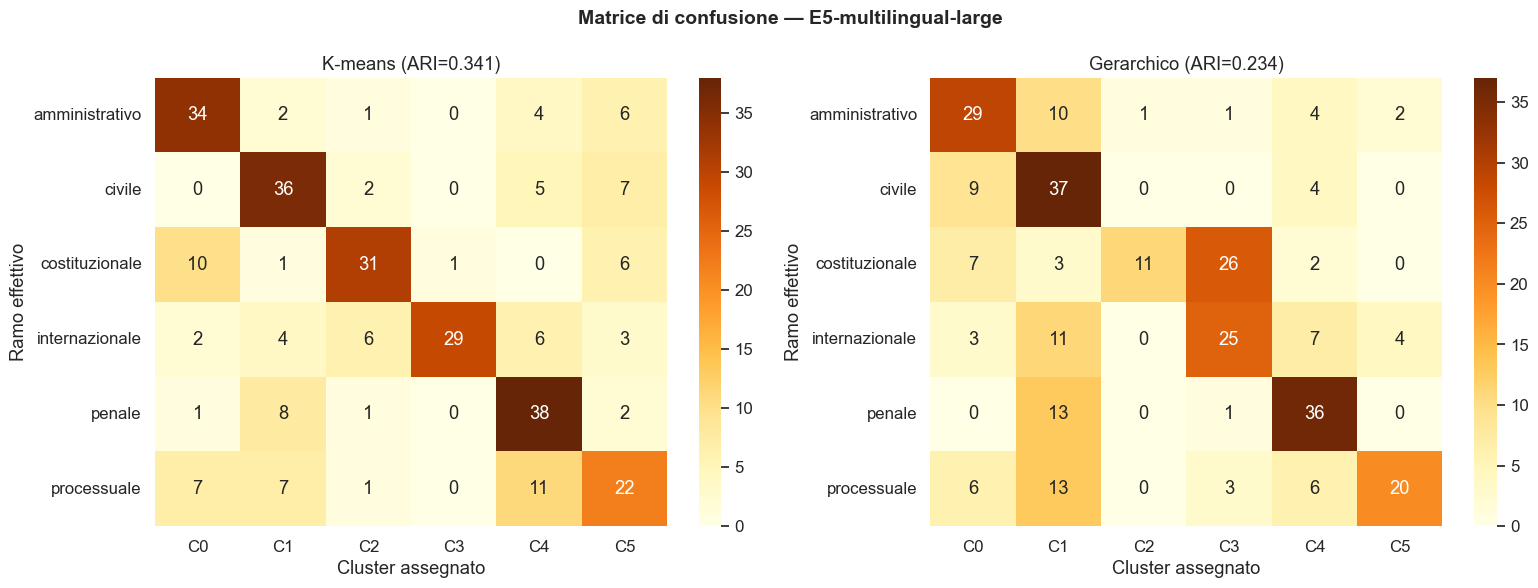

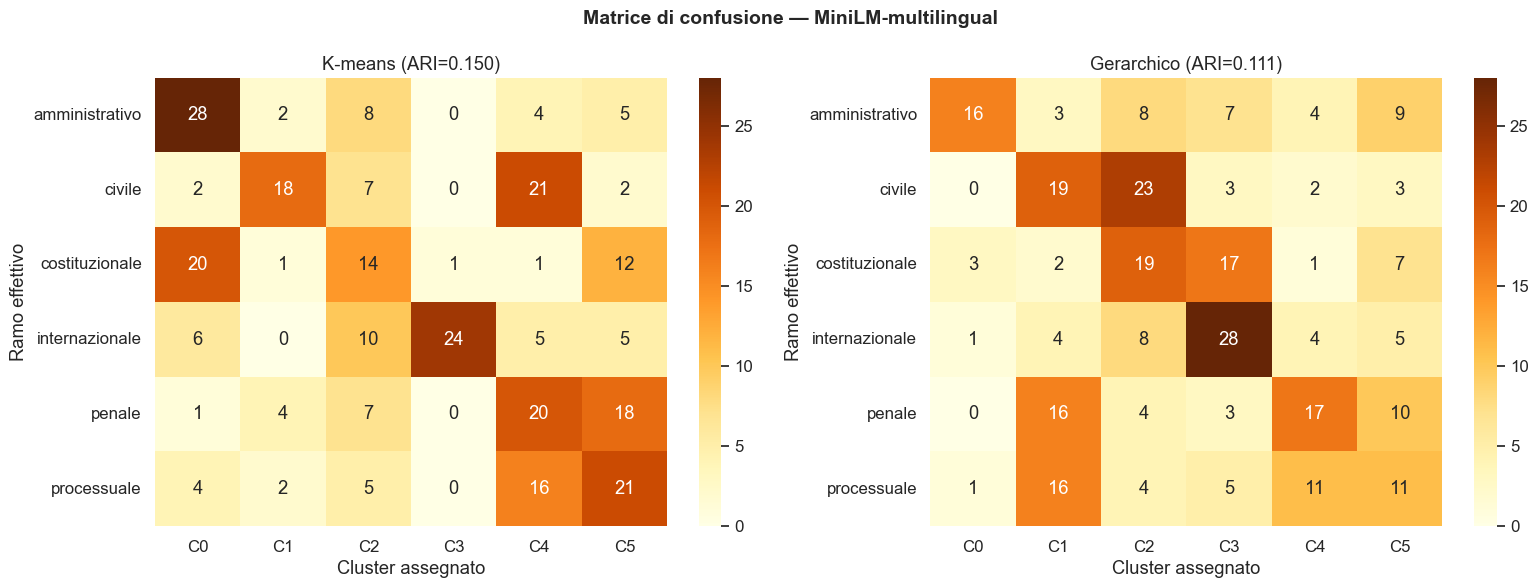

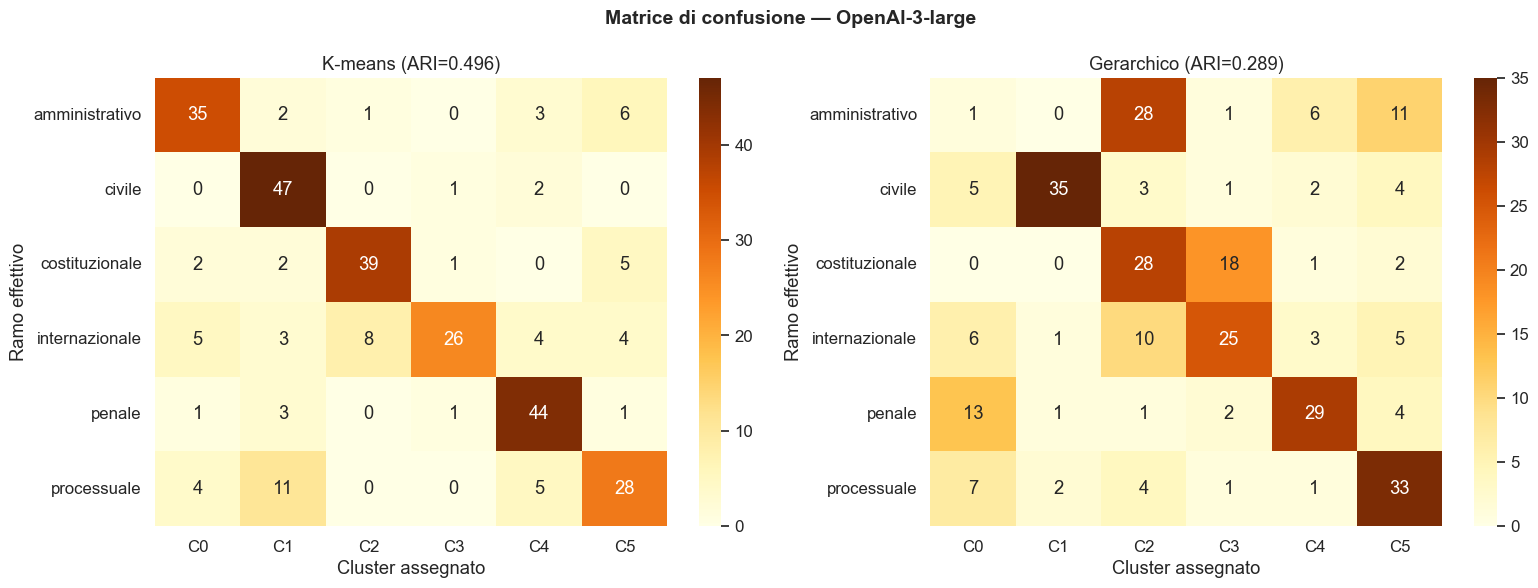

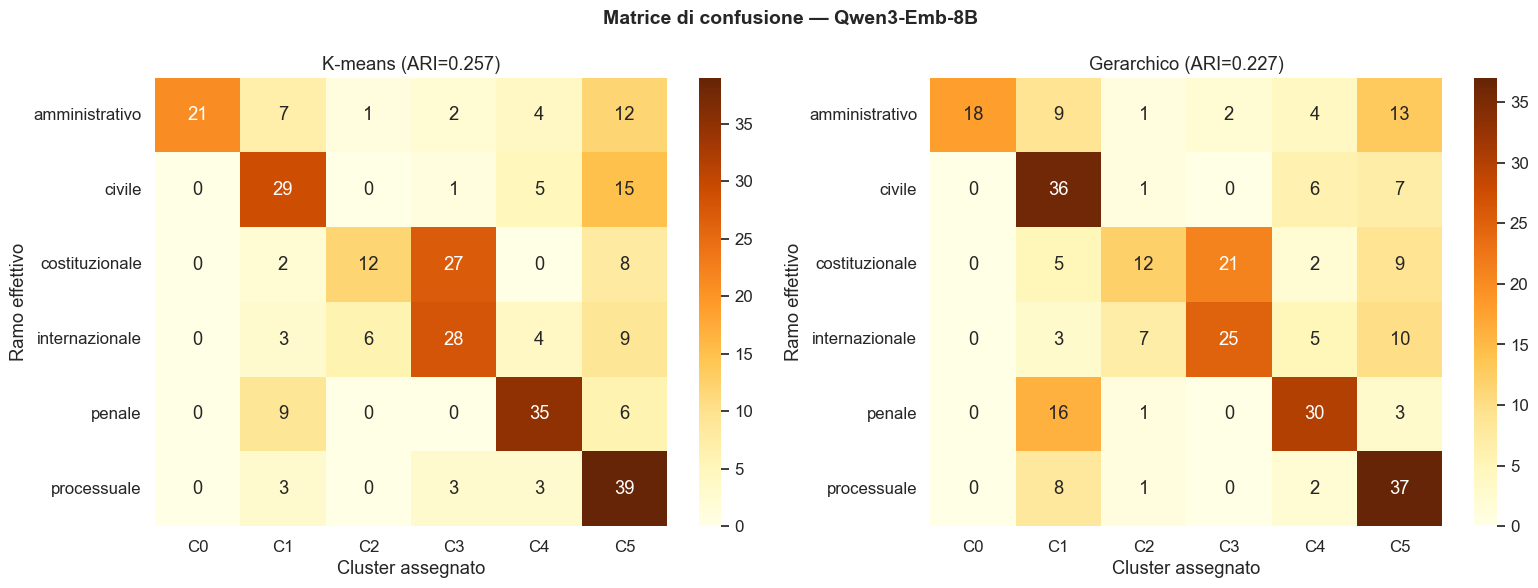

In [29]:
# == 5.1 Matrice di confusione =====================================

for model_label, mr in results.items():
    fig, axes_cm = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"Matrice di confusione — {model_label}", fontsize=14, fontweight="bold")

    for ax, (algo, key, mkey) in zip(axes_cm, [
        ("K-means", "kmeans", "kmeans_metrics"),
        ("Gerarchico", "hierarchical", "hier_metrics"),
    ]):
        pred = mr[key]
        cm = confusion_matrix(labels_true, pred)

        # Riordina colonne per massimizzare la diagonale (Hungarian algorithm)
        n = min(cm.shape)
        if cm.shape[1] < cm.shape[0]:
            cm = np.pad(cm, ((0, 0), (0, cm.shape[0] - cm.shape[1])))
        _, col_ind = linear_sum_assignment(-cm[:n, :n])
        cm_r = cm[:, col_ind] if len(col_ind) == cm.shape[1] else cm

        sns.heatmap(
            cm_r, annot=True, fmt="d", cmap="YlOrBr",
            xticklabels=[f"C{i}" for i in range(cm_r.shape[1])],
            yticklabels=rami_unique, ax=ax,
        )
        ax.set_xlabel("Cluster assegnato")
        ax.set_ylabel("Ramo effettivo")
        ax.set_title(f"{algo} (ARI={mr[mkey]['ARI']:.3f})")

    plt.tight_layout()
    plt.show()

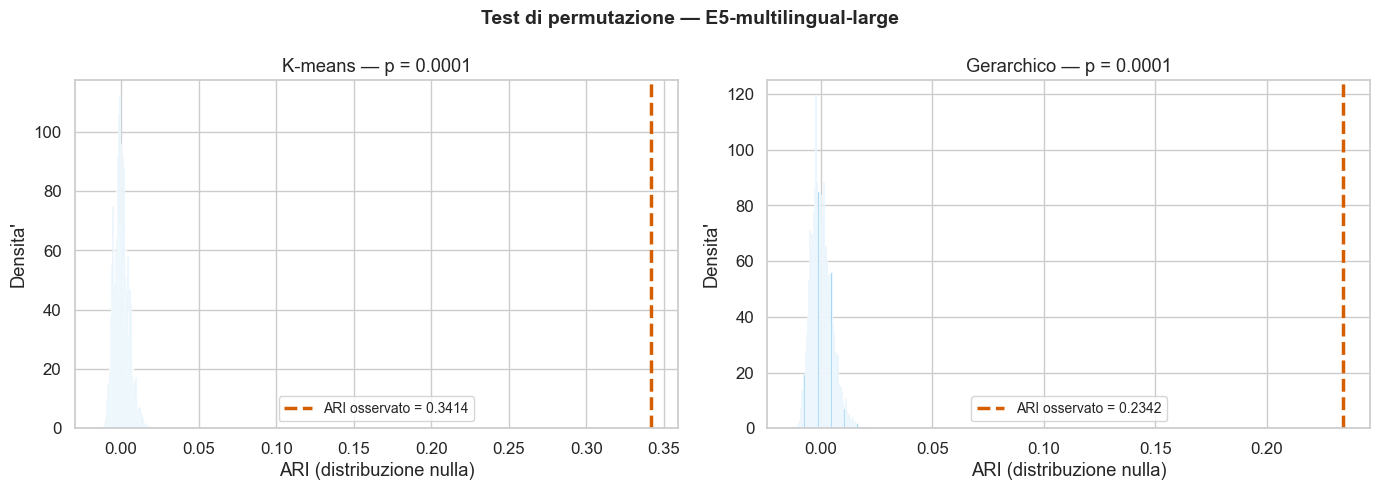

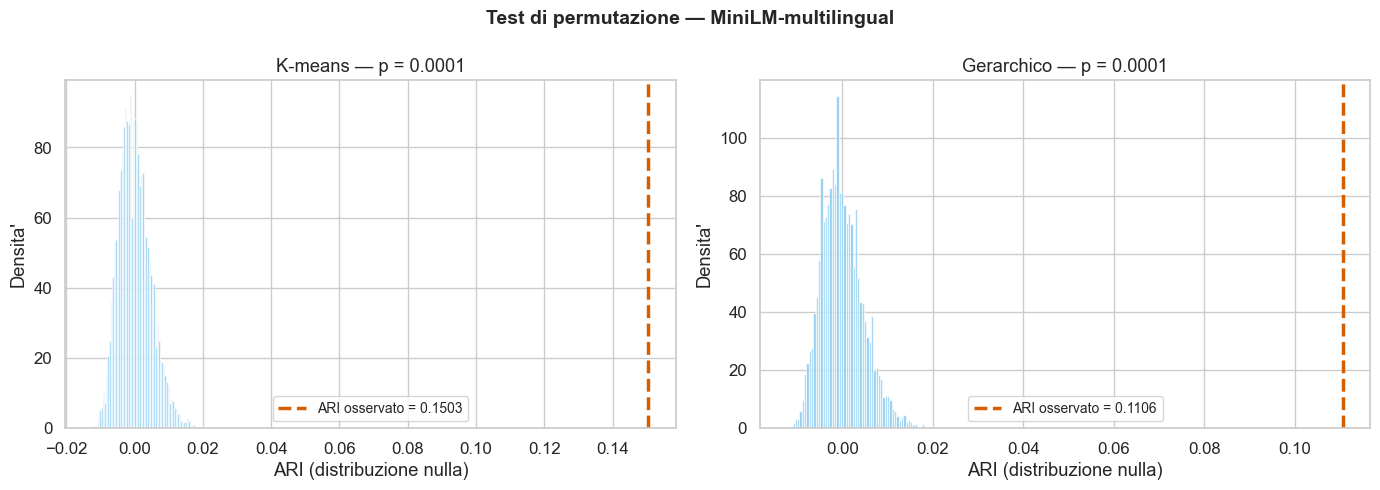

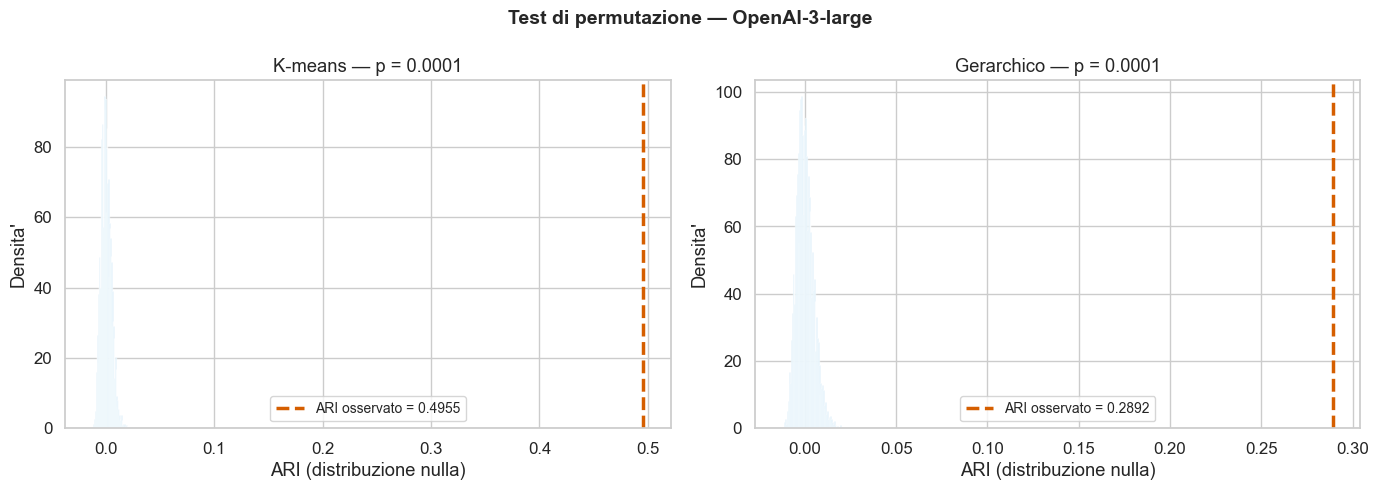

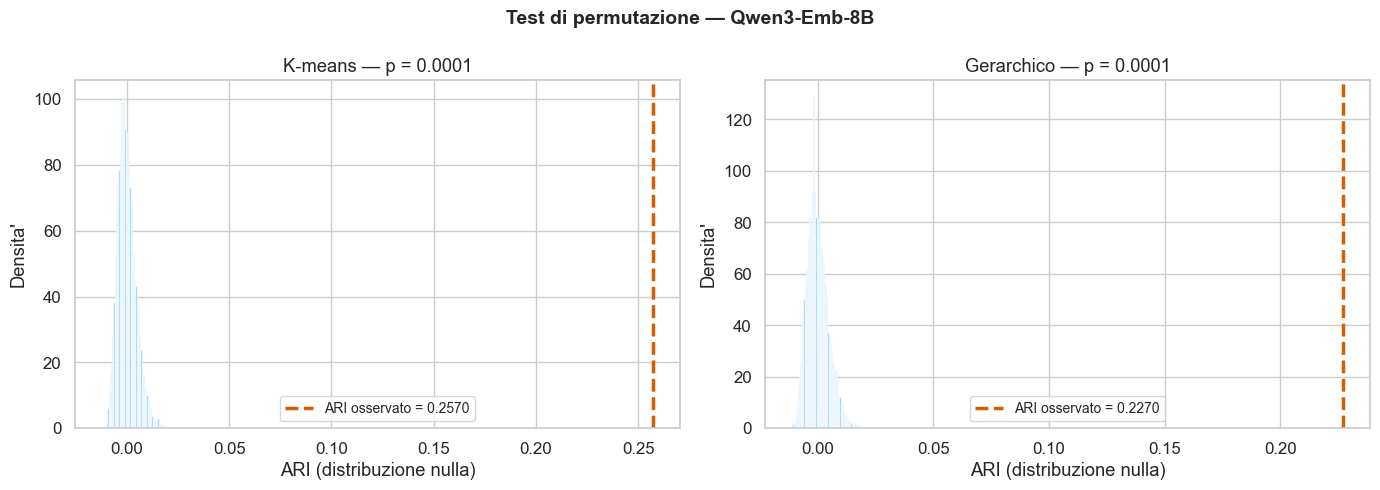

In [30]:
# == 5.2 Distribuzione nulla =======================================

for model_label, mr in results.items():
    fig, axes_nd = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Test di permutazione — {model_label}", fontsize=14, fontweight="bold")

    for ax, (algo, key, mkey) in zip(axes_nd, [
        ("K-means", "kmeans", "kmeans_metrics"),
        ("Gerarchico", "hierarchical", "hier_metrics"),
    ]):
        null_key = f"{key}_null"
        if null_key not in mr:
            continue
        null_dist = mr[null_key]
        ari_obs = mr[mkey]["ARI"]
        p_val = mr[mkey]["p_value"]

        ax.hist(null_dist, bins=80, density=True, alpha=0.7,
                color="#56B4E9", edgecolor="white")
        ax.axvline(ari_obs, color="#D55E00", linewidth=2.5, linestyle="--",
                   label=f"ARI osservato = {ari_obs:.4f}")
        ax.set_xlabel("ARI (distribuzione nulla)")
        ax.set_ylabel("Densita'")
        ax.set_title(f"{algo} — p = {p_val:.4f}")
        ax.legend(fontsize=10)

    plt.tight_layout()
    plt.show()

In [31]:
# == 5.3 UMAP 2D — Mappa del diritto italiano =====================

if HAS_UMAP:
    for model_label, emb in embeddings.items():
        reducer = umap.UMAP(
            n_neighbors=15, min_dist=0.1, metric="cosine",
            random_state=SEED, n_components=2,
        )
        coords = reducer.fit_transform(emb)

        fig, ax = plt.subplots(figsize=(14, 10))

        for ramo in rami_unique:
            mask = df["ramo"].values == ramo
            ax.scatter(
                coords[mask, 0], coords[mask, 1],
                label=ramo, color=PALETTE[ramo],
                s=45, alpha=0.75, edgecolors="white", linewidth=0.5,
            )
            # Etichette: campione di 5 termini non-trasversali per leggibilita'
            ramo_df = df[mask & ~df["trasversale"]]
            sample = ramo_df.sample(min(5, len(ramo_df)), random_state=SEED)
            for _, row in sample.iterrows():
                idx = df.index.get_loc(row.name)
                ax.annotate(
                    row["termine"], (coords[idx, 0], coords[idx, 1]),
                    fontsize=6.5, alpha=0.85,
                    xytext=(5, 5), textcoords="offset points",
                )

        # Cerchi vuoti per i trasversali
        mask_t = df["trasversale"].values
        if mask_t.any():
            ax.scatter(
                coords[mask_t, 0], coords[mask_t, 1],
                facecolors="none", edgecolors="black", s=120,
                linewidth=1.5, label="trasversale", zorder=5,
            )

        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")
        ax.set_title(
            f"Mappa del diritto italiano nello spazio degli embedding\n{model_label}",
            fontsize=13, fontweight="bold",
        )
        ax.legend(loc="best", fontsize=9, framealpha=0.9)
        plt.tight_layout()
        plt.show()
else:
    print("UMAP non disponibile. Installare con: pip install umap-learn")

TypeError: check_array() got an unexpected keyword argument 'force_all_finite'

In [ ]:
# == 5.4 Tabella riepilogativa =====================================

rows = []
for model_label, mr in results.items():
    for algo, key, mkey in [
        ("K-means", "kmeans", "kmeans_metrics"),
        ("Gerarchico", "hierarchical", "hier_metrics"),
    ]:
        m = mr[mkey]
        rows.append({
            "Modello": model_label,
            "Algoritmo": algo,
            "ARI": f"{m['ARI']:.4f}",
            "NMI": f"{m['NMI']:.4f}",
            "V-measure": f"{m['V-measure']:.4f}",
            "Silhouette": f"{m['Silhouette']:.4f}",
            "p-value": f"{m.get('p_value', 'N/A')}",
        })
    if "hdbscan_metrics" in mr:
        hm = mr["hdbscan_metrics"]
        rows.append({
            "Modello": model_label,
            "Algoritmo": f"HDBSCAN (k={hm['n_clusters']})",
            "ARI": f"{hm['ARI']:.4f}" if not np.isnan(hm['ARI']) else "-",
            "NMI": f"{hm['NMI']:.4f}" if not np.isnan(hm['NMI']) else "-",
            "V-measure": "-",
            "Silhouette": f"{hm['Silhouette']:.4f}" if not np.isnan(hm['Silhouette']) else "-",
            "p-value": "-",
        })

df_summary = pd.DataFrame(rows)
print("TABELLA RIEPILOGATIVA")
print("Esperimento 1: Tassonomia Emergente")
print("=" * 90)
display(df_summary)

TABELLA RIEPILOGATIVA
Esperimento 1: Tassonomia Emergente


,Modello,Algoritmo,ARI,NMI,V-measure,Silhouette,p-value
0,E5-multilingual-large,K-means,0.3414,0.4048,0.4048,0.0725,9.999000099990002e-05
1,E5-multilingual-large,Gerarchico,0.2342,0.3314,0.3314,0.0507,9.999000099990002e-05
2,MiniLM-multilingual,K-means,0.1503,0.2469,0.2469,0.1349,9.999000099990002e-05
3,MiniLM-multilingual,Gerarchico,0.1106,0.1761,0.1761,0.0708,9.999000099990002e-05
4,OpenAI-3-large,K-means,0.4955,0.5288,0.5288,0.0503,9.999000099990002e-05
5,OpenAI-3-large,Gerarchico,0.2892,0.3654,0.3654,0.0464,9.999000099990002e-05
6,Qwen3-Emb-8B,K-means,0.2567,0.3553,0.3553,0.0804,9.999000099990002e-05
7,Qwen3-Emb-8B,Gerarchico,0.2291,0.3342,0.3342,0.0566,9.999000099990002e-05


## Sezione 6: Analisi dei termini trasversali

### Perche' i termini trasversali sono importanti

I termini annotati come "trasversali" appartengono a piu' di un ramo del diritto (es. "nullita'" e' sia civile che processuale; "confisca" e' sia penale che amministrativa). Sono il **test piu' informativo** dell'esperimento perche' mettono alla prova la capacita' del modello di catturare la *complessita'* della tassonomia, non solo le distinzioni nette.

### Tre possibili esiti

1. **Il clustering li assegna al ramo dominante**: il modello cattura la specializzazione prevalente del termine. Es. "confisca" viene assegnata al cluster penale perche' il modello l'ha vista prevalentemente in contesti penalistici. Questo e' informativo: rivela quale ramo "possiede" il termine nello spazio semantico del modello.

2. **Il clustering li distribuisce tra piu' cluster**: ogni termine finisce nel cluster del ramo con cui ha piu' affinita'. Questo suggerisce che il modello riconosce la natura inter-ramo del termine.

3. **HDBSCAN li classifica come noise**: i termini trasversali non hanno abbastanza densita' in nessun cluster specifico. Questo sarebbe l'esito piu' interessante: il modello distingue attivamente il lessico trasversale da quello specializzato.

### Metodo di analisi

Per ciascun algoritmo di clustering:
1. Costruire la mappa **cluster → ramo dominante** (il ramo piu' frequente in ciascun cluster)
2. Per ciascun termine trasversale, verificare se il cluster assegnato corrisponde al ramo primario annotato
3. Calcolare la percentuale di assegnamenti "corretti" (al ramo primario)

I casi in cui l'assegnamento diverge dal ramo primario sono i piu' interessanti per l'analisi qualitativa: richiedono una valutazione giuridica (il clustering sbaglia, o rivela una prossimita' non prevista?).

In [ ]:
# == Analisi termini trasversali ===================================

mask_trasv = df["trasversale"].values
df_trasv = df[mask_trasv].copy()

print(f"Termini trasversali: {len(df_trasv)}")
print(f"  Per ramo primario:")
print(df_trasv["ramo"].value_counts().to_string())

for model_label, mr in results.items():
    print(f"\n{'='*70}")
    print(f"  {model_label}")
    print(f"{'='*70}")

    km_labels = mr["kmeans"]

    # Mappa cluster -> ramo dominante
    cluster_to_ramo = {}
    for c in range(n_rami):
        mask_c = km_labels == c
        if mask_c.any():
            cluster_to_ramo[c] = Counter(rami[mask_c]).most_common(1)[0][0]

    print(f"  Mappa cluster -> ramo: {cluster_to_ramo}")
    print(f"\n  {'Termine':<42s} {'Ramo':<16s} {'Cl.':<5s} {'Ramo cl.':<16s} {'OK?'}")
    print(f"  {'─'*85}")

    n_match = 0
    for idx in df_trasv.index:
        row = df.loc[idx]
        c = km_labels[idx]
        rc = cluster_to_ramo.get(c, "?")
        match = rc == row["ramo"]
        n_match += int(match)
        print(f"  {row['termine']:<42s} {row['ramo']:<16s} {c:<5d} {rc:<16s} {'v' if match else 'x'}")

    print(f"\n  Trasversali assegnati al ramo primario: {n_match}/{len(df_trasv)} ({100*n_match/len(df_trasv):.0f}%)")

Termini trasversali: 22
  Per ramo primario:
ramo
costituzionale    7
processuale       7
penale            4
civile            2
amministrativo    2

  E5-multilingual-large
  Mappa cluster -> ramo: {0: 'internazionale', 1: 'civile', 2: 'amministrativo', 3: 'penale', 4: 'processuale', 5: 'costituzionale'}

  Termine                                    Ramo             Cl.   Ramo cl.         OK?
  ─────────────────────────────────────────────────────────────────────────────────────
  stato di necessita'                        penale           2     amministrativo   x
  nesso causale                              penale           1     civile           x
  danneggiamento                             penale           3     penale           v
  confisca                                   penale           3     penale           v
  nullita'                                   civile           1     civile           v
  espropriazione                             civile           3     penale     

## Sezione 7: Analisi multi-k

### La domanda

Abbiamo prescritto $k=6$ perche' la dottrina riconosce 6 rami del diritto. Ma **e' davvero 6 la partizione "naturale"** dello spazio degli embedding?

### Il metodo

Ripetiamo K-means per $k = 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20$ e per ciascun $k$ calcoliamo l'ARI rispetto ai 6 rami reali.

Se il picco dell'ARI si trova a $k=6$, e' forte evidenza che la tassonomia a 6 rami e' la partizione ottimale anche dal punto di vista geometrico: nessun'altra granularita' corrisponde meglio alle etichette dottrinali.

### Scenari interpretativi

- **Picco a k=6**: la tassonomia tradizionale e' la partizione naturale. Forte conferma.
- **Picco a k=2 o k=3**: il modello cattura solo le macro-distinzioni (es. pubblico/privato, o sostanziale/processuale/internazionale). I rami fini non sono separati geometricamente.
- **Picco a k > 6**: il modello suggerisce una granularita' piu' fine della tassonomia. Potrebbe indicare sotto-rami rilevanti (es. il penale si divide in sostanziale e processuale).
- **ARI piatto (nessun picco chiaro)**: la struttura e' debole o il modello non cattura la tassonomia a nessuna granularita'.

### Nota tecnica: il Silhouette score

Si potrebbe anche usare il Silhouette score come funzione di $k$ per trovare il $k$ ottimale *senza* le etichette dei rami. Se il Silhouette ha un massimo nello stesso punto dell'ARI, la struttura e' coerente: il $k$ che meglio separa i cluster geometricamente e' anche quello che meglio corrisponde ai rami.

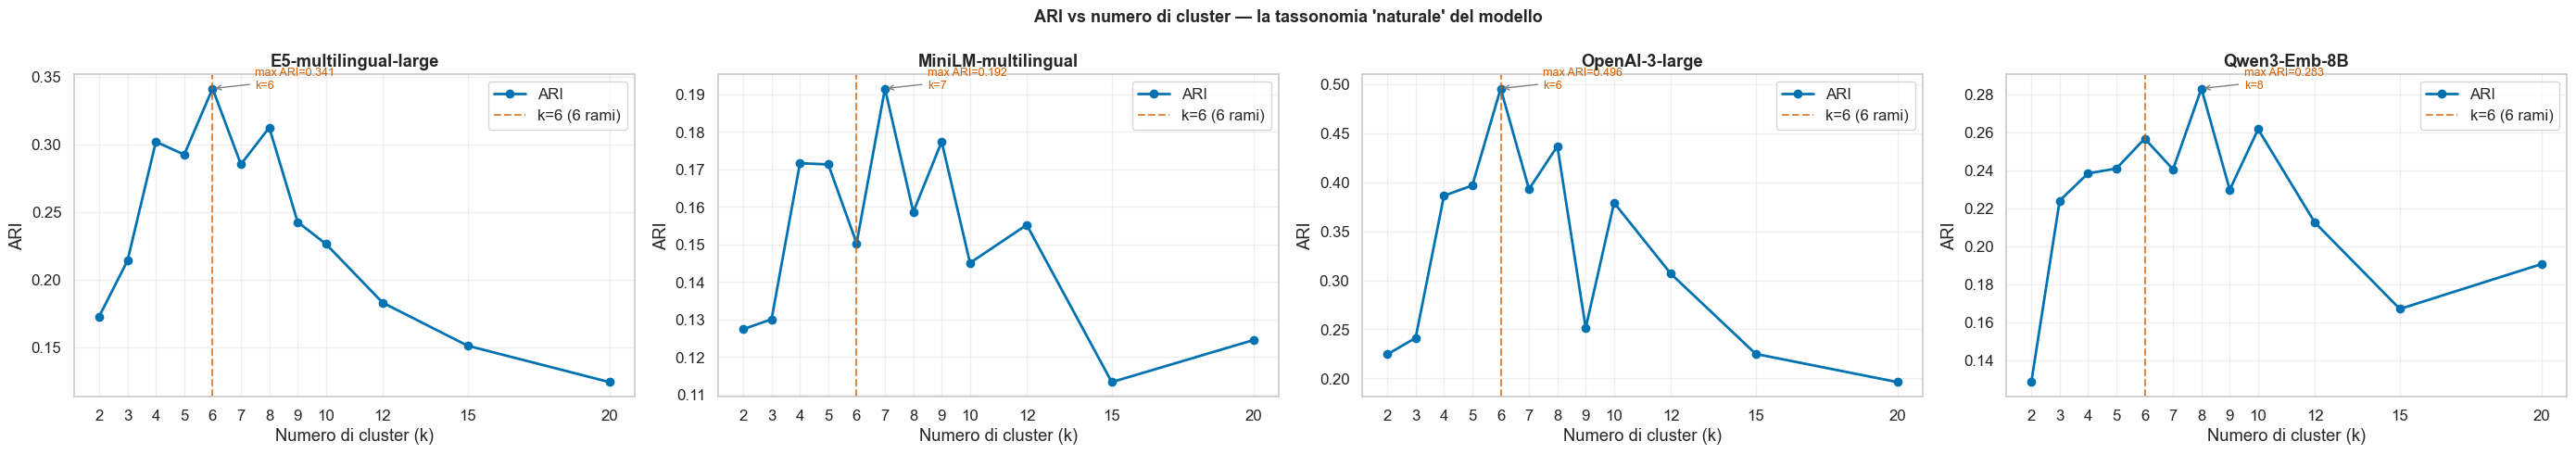

In [ ]:
# == Analisi multi-k ===============================================

k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20]

fig, axes_mk = plt.subplots(1, len(embeddings), figsize=(7 * len(embeddings), 5))
if len(embeddings) == 1:
    axes_mk = [axes_mk]

for ax, (model_label, emb) in zip(axes_mk, embeddings.items()):
    ari_scores = []
    sil_scores = []

    for k in k_values:
        km = KMeans(n_clusters=k, random_state=SEED, n_init=20)
        pred = km.fit_predict(emb)
        ari_scores.append(adjusted_rand_score(labels_true, pred))
        sil_scores.append(silhouette_score(emb, pred, metric="cosine"))

    ax.plot(k_values, ari_scores, "o-", color="#0072B2", linewidth=2, label="ARI")
    ax.axvline(n_rami, color="#D55E00", linestyle="--", alpha=0.7,
               label=f"k={n_rami} (6 rami)")

    best_k = k_values[np.argmax(ari_scores)]
    best_ari = max(ari_scores)
    ax.annotate(
        f"max ARI={best_ari:.3f}\nk={best_k}",
        xy=(best_k, best_ari), xytext=(best_k + 1.5, best_ari),
        arrowprops=dict(arrowstyle="->", color="gray"),
        fontsize=9, color="#D55E00",
    )

    ax.set_xlabel("Numero di cluster (k)")
    ax.set_ylabel("ARI")
    ax.set_title(f"{model_label}", fontweight="bold")
    ax.legend()
    ax.set_xticks(k_values)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "ARI vs numero di cluster — la tassonomia 'naturale' del modello",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.show()

## Sezione 8: Interpretazione dei risultati

### Quadro valutativo

L'Esperimento 1 produce una quantita' considerevole di dati numerici. Per trarne conclusioni rigorose senza introdurre bias, il lettore deve effettuare una serie di **confronti sistematici**. Questa sezione li elenca tutti, senza suggerire quale risultato sia "buono" o "cattivo" — il giudizio spetta al lettore.

---

### 8.1 Griglia di valutazione dell'ARI

L'ARI e' la metrica primaria. Per orientarsi, si puo' collocare il valore osservato su questa scala (derivata dalla letteratura sul clustering):

| ARI | Descrizione operativa |
|-----|----------------------|
| $> 0.65$ | Concordanza forte: la maggior parte dei termini e' nel cluster "giusto" |
| $0.40 - 0.65$ | Concordanza moderata: la struttura e' riconoscibile con errori |
| $0.20 - 0.40$ | Concordanza debole: solo alcune macro-distinzioni emergono |
| $0.05 - 0.20$ | Concordanza marginale: appena sopra il caso |
| $< 0.05$ | Concordanza nulla: indistinguibile dal caso |

**Attenzione**: queste soglie sono convenzionali, non assolute. Un ARI di 0.35 con $p < 0.001$ e' statisticamente significativo (la struttura esiste) anche se moderato (la struttura e' parziale). La significativita' e l'entita' dell'effetto sono informazioni complementari, non interscambiabili.

---

### 8.2 Confronti da effettuare

Il lettore dovrebbe compilare mentalmente (o su carta) la seguente griglia:

#### Confronto 1: Consistenza tra algoritmi (stesso modello)

Per ciascun modello, confrontare:

| | K-means | Gerarchico (Ward) | HDBSCAN |
|---|---|---|---|
| ARI | $\text{ARI}_{\text{km}}$ | $\text{ARI}_{\text{ward}}$ | $\text{ARI}_{\text{hdb}}$ |
| p-value | $p_{\text{km}}$ | $p_{\text{ward}}$ | — |

- Se tutti e tre gli ARI sono simili ($|\Delta| < 0.1$): la struttura e' **robusta** rispetto al metodo
- Se divergono fortemente: la struttura dipende dalle assunzioni dell'algoritmo — conclusione piu' debole
- Se solo HDBSCAN diverge: attenzione al numero di cluster $k$ trovato (potrebbe essere diverso da 6)

#### Confronto 2: Consistenza tra modelli (stesso algoritmo)

Per K-means (l'algoritmo piu' diretto), confrontare i modelli:

| | Modello 1 | Modello 2 | ... | Modello N |
|---|---|---|---|---|
| ARI | | | | |
| Silhouette | | | | |

- Se tutti i modelli danno ARI simili: la struttura e' **indipendente dal modello** (evidenza forte)
- Se un modello e' nettamente superiore: la struttura dipende dalla rappresentazione — verificare se e' correlata alla dimensionalita', alla specializzazione linguistica, o al corpus di addestramento
- Se nessun modello supera ARI = 0.20: la struttura tassonomica potrebbe non essere presente negli embedding di parole singole

#### Confronto 3: HDBSCAN $k$ vs $k = 6$

| Modello | $k$ trovato da HDBSCAN | $\%$ rumore | Interpretazione |
|---------|----------------------|------------|----------------|
| | | | $k = 6$: conferma indipendente |
| | | | $k < 6$: alcuni rami si fondono — quali? |
| | | | $k > 6$: sotto-struttura piu' fine — si frammenta quale ramo? |
| | | | $k = 1$: nessuna struttura cluster |

#### Confronto 4: Matrice di confusione — pattern di errore

Per ciascun modello, identificare le confusioni piu' frequenti e compilare:

| Ramo $i$ | Ramo $j$ | $M_{ij}$ (termini confusi) | Plausibilita' dottrinale |
|----------|----------|---------------------------|-------------------------|
| | | | Il lettore giudica: questa confusione ha senso giuridico? |

Alcune confusioni possono essere *informative*: se il modello confonde "processuale" e "penale", potrebbe riflettere il fatto che il lessico processuale penale e' diverso da quello processuale civile. Altre confusioni possono essere *artefattuali*: se il modello confonde rami che non hanno nulla in comune, il problema e' nella rappresentazione.

#### Confronto 5: Silhouette score

| Interpretazione del Silhouette | Significato |
|-------------------------------|-------------|
| $> 0.25$ per tutti i modelli | I cluster sono geometricamente separati — la struttura e' anche *metrica*, non solo *topologica* |
| $0.05 - 0.25$ | I cluster esistono ma si sovrappongono — la struttura e' presente ma i confini sono sfumati |
| $< 0.05$ | I cluster non sono geometricamente separati — la corrispondenza ARI potrebbe essere "fortunata" |

Se ARI e' alto ma Silhouette e' basso: i rami si distinguono per composizione (i termini "gravitano" verso il cluster giusto) ma non per separazione geometrica (i confini tra cluster sono diffusi). Questo e' un risultato valido ma piu' debole di una separazione netta.

#### Confronto 6: Termini trasversali (Sezione 6)

| Termine trasversale | Cluster assegnato | Ramo formale | Il cluster corrisponde al ramo? |
|--------------------|-------------------|-------------|-------------------------------|
| | | | Se no: verso quale ramo "gravita"? |

I termini trasversali sono il test piu' fine. Se vengono assegnati coerentemente (sempre allo stesso cluster tra modelli diversi), il modello ha una rappresentazione stabile del termine. Se "vagano" tra cluster, la loro posizione e' instabile — zona di confine semantico.

#### Confronto 7: Multi-k (Sezione 7)

| $k$ | ARI medio tra modelli | Silhouette medio | $k$ ottimale? |
|-----|----------------------|-----------------|--------------|
| 2 | | | |
| 3 | | | |
| ... | | | |
| 10 | | | |

- Se il picco di ARI e' a $k = 6$: la tassonomia a 6 rami e' la granularita' ottimale
- Se il picco e' a $k = 2$-$3$: il modello vede macro-distinzioni (pubblico/privato? sostanziale/processuale?) ma non i singoli rami
- Se il picco e' a $k > 6$: il modello vede sotto-strutture all'interno dei rami — possibile granularita' piu' fine della tassonomia
- Se nessun picco chiaro: la struttura non ha una granularita' privilegiata

---

### 8.3 Scenari interpretativi complessivi

Dopo aver completato i confronti sopra, il lettore puo' collocare i risultati in uno dei seguenti scenari:

| Scenario | Condizioni necessarie | Implicazione per la teoria |
|----------|-----------------------|---------------------------|
| **A** | ARI $> 0.5$ per almeno 2 modelli, HDBSCAN $k \approx 6$, p $< 0.001$, pattern stabile tra algoritmi | La tassonomia e' geometricamente presente nello spazio degli embedding |
| **B** | ARI $0.25$-$0.50$, HDBSCAN $k = 3$-$5$, p $< 0.01$, alcune confusioni sistematiche | La struttura e' parziale: alcune distinzioni emergono, altre no |
| **C** | ARI $0.10$-$0.25$, HDBSCAN $k = 2$-$3$, p $< 0.05$ solo per alcuni modelli | Solo le macro-distinzioni sono catturate (pubblico/privato? sostanziale/processuale?) |
| **D** | ARI $< 0.10$ per tutti i modelli, p $> 0.05$, pattern incoerente tra algoritmi | La struttura tassonomica non e' catturata dagli embedding di parole singole |

**Nessuno di questi scenari e' "il risultato giusto"**. Ciascuno e' informativo:
- **A** significa che i modelli di linguaggio catturano la struttura del diritto — forte evidenza per la teoria
- **B** significa che la catturano parzialmente — la teoria e' promettente ma richiede raffinamento
- **C** significa che solo la struttura piu' grossolana emerge — i modelli generalisti non hanno la risoluzione per le distinzioni fini del diritto
- **D** significa che gli embedding di parole singole non sono il livello giusto di analisi — ma non confuta la teoria nel suo complesso (le frasi contestualizzate, oggetto di esperimenti futuri, potrebbero dare risultati diversi)

---

### 8.4 Confound e limiti

Anche in caso di risultato positivo (Scenario A o B), il lettore deve considerare:

| Confound | Rischio | Come e' controllato |
|----------|---------|-------------------|
| **Frequenza lessicale** | Termini rari hanno embedding meno stabili | Tutti i termini sono tecnico-giuridici di frequenza comparabile |
| **Overlap lessicale** | "diritto penale" e "diritto civile" condividono "diritto" | Controllato in Sezione 6 (trasversali) e nell'Esperimento 2 |
| **Numero di rami** | $k = 6$ e' imposto nell'Esperimento 1 | Multi-k (Sezione 7) e HDBSCAN verificano se $k = 6$ e' la scelta giusta |
| **Normalizzazione L2** | K-means su vettori unitari equivale a cosine K-means — potrebbe non essere ottimale | Ward e HDBSCAN non hanno questa limitazione; concordanza tra i tre metodi mitiga |
| **Scelta dei termini** | Il lessico e' costruito dal ricercatore | 294 termini da 6 rami, bilanciati (47-50 per ramo), con motivazione per ciascuno |
| **Modello unico** | Risultati di un solo modello non sono generalizzabili | Confronto tra modelli diversi (multilingui, dimensioni diverse, corpora diversi) |

---

### 8.5 Connessione con gli esperimenti successivi

L'Esperimento 1 stabilisce la *baseline tassonomica*. I risultati condizionano l'interpretazione degli esperimenti successivi:

| Risultato Exp. 1 | Implicazione per Exp. 2 (Distanza tra Istituti) |
|-------------------|------------------------------------------------|
| ARI alto, cluster ben separati | Ci aspettiamo che coppie intra-ramo siano piu' vicine di coppie inter-ramo |
| ARI basso, cluster sovrapposti | Le distanze dell'Exp. 2 potrebbero non seguire l'ordinamento previsto |
| Confusione sistematica tra rami $i$ e $j$ | Le coppie che coinvolgono termini di $i$ e $j$ saranno piu' vicine del previsto |

**Importante**: l'Esperimento 2 puo' dare risultati positivi anche se l'Esperimento 1 da' risultati modesti. La struttura metrica (distanze) potrebbe essere piu' informativa della struttura categoriale (cluster). I due esperimenti testano proprieta' diverse dello spazio degli embedding.

In [ ]:
# == 8.1 Tabella ARI: collocamento nella griglia di valutazione ====

def _ari_band(ari):
    if ari > 0.65: return "> 0.65  (forte)"
    if ari > 0.40: return "0.40-0.65 (moderata)"
    if ari > 0.20: return "0.20-0.40 (debole)"
    if ari > 0.05: return "0.05-0.20 (marginale)"
    return "< 0.05  (nulla)"

rows_grid = []
for model_label, mr in results.items():
    for algo, mkey in [("K-means", "kmeans_metrics"), ("Gerarchico", "hier_metrics")]:
        m = mr[mkey]
        rows_grid.append({
            "Modello": model_label,
            "Algoritmo": algo,
            "ARI": f"{m['ARI']:.4f}",
            "Fascia": _ari_band(m["ARI"]),
            "p-value": f"{m.get('p_value', float('nan')):.2e}",
            "Significativo?": "si'" if m.get("p_value", 1) < 0.05 else "no",
        })
    if "hdbscan_metrics" in mr:
        hm = mr["hdbscan_metrics"]
        ari_val = hm["ARI"]
        if not np.isnan(ari_val):
            rows_grid.append({
                "Modello": model_label,
                "Algoritmo": f"HDBSCAN (k={hm['n_clusters']})",
                "ARI": f"{ari_val:.4f}",
                "Fascia": _ari_band(ari_val),
                "p-value": "-",
                "Significativo?": "-",
            })

print("=" * 90)
print("  CONFRONTO 0: Collocamento ARI nella griglia di valutazione")
print("=" * 90)
display(pd.DataFrame(rows_grid))

  CONFRONTO 0: Collocamento ARI nella griglia di valutazione


,Modello,Algoritmo,ARI,Fascia,p-value,Significativo?
0,E5-multilingual-large,K-means,0.3414,0.20-0.40 (debole),1.00e-04,si'
1,E5-multilingual-large,Gerarchico,0.2342,0.20-0.40 (debole),1.00e-04,si'
2,MiniLM-multilingual,K-means,0.1503,0.05-0.20 (marginale),1.00e-04,si'
3,MiniLM-multilingual,Gerarchico,0.1106,0.05-0.20 (marginale),1.00e-04,si'
4,MiniLM-multilingual,HDBSCAN (k=2),0.1821,0.05-0.20 (marginale),-,-
5,OpenAI-3-large,K-means,0.4848,0.40-0.65 (moderata),1.00e-04,si'
6,OpenAI-3-large,Gerarchico,0.2892,0.20-0.40 (debole),1.00e-04,si'
7,Qwen3-Emb-8B,K-means,0.2211,0.20-0.40 (debole),1.00e-04,si'
8,Qwen3-Emb-8B,Gerarchico,0.2291,0.20-0.40 (debole),1.00e-04,si'


In [ ]:
# == 8.2a Confronto 1: Consistenza tra algoritmi (stesso modello) ==

print("=" * 90)
print("  CONFRONTO 1: Consistenza tra algoritmi (stesso modello)")
print("  Se |delta ARI| < 0.10 tra algoritmi => struttura robusta rispetto al metodo")
print("=" * 90)

rows_c1 = []
for model_label, mr in results.items():
    ari_km = mr["kmeans_metrics"]["ARI"]
    ari_wd = mr["hier_metrics"]["ARI"]
    ari_hdb = mr["hdbscan_metrics"]["ARI"] if "hdbscan_metrics" in mr else float("nan")

    rows_c1.append({
        "Modello": model_label,
        "ARI K-means": f"{ari_km:.4f}",
        "ARI Ward": f"{ari_wd:.4f}",
        "ARI HDBSCAN": f"{ari_hdb:.4f}" if not np.isnan(ari_hdb) else "-",
        "|KM - Ward|": f"{abs(ari_km - ari_wd):.4f}",
        "|KM - HDB|": f"{abs(ari_km - ari_hdb):.4f}" if not np.isnan(ari_hdb) else "-",
        "Consistente?": (
            "si'" if abs(ari_km - ari_wd) < 0.10
            and (np.isnan(ari_hdb) or abs(ari_km - ari_hdb) < 0.10)
            else "parziale" if abs(ari_km - ari_wd) < 0.15
            else "no"
        ),
    })

display(pd.DataFrame(rows_c1))

  CONFRONTO 1: Consistenza tra algoritmi (stesso modello)
  Se |delta ARI| < 0.10 tra algoritmi => struttura robusta rispetto al metodo


,Modello,ARI K-means,ARI Ward,ARI HDBSCAN,|KM - Ward|,|KM - HDB|,Consistente?
0,E5-multilingual-large,0.3414,0.2342,-,0.1073,-,parziale
1,MiniLM-multilingual,0.1503,0.1106,0.1821,0.0397,0.0318,si'
2,OpenAI-3-large,0.4848,0.2892,-,0.1957,-,no
3,Qwen3-Emb-8B,0.2211,0.2291,-,0.0080,-,si'


In [ ]:
# == 8.2b Confronto 2: Consistenza tra modelli (K-means) ===========

print("=" * 90)
print("  CONFRONTO 2: Consistenza tra modelli (algoritmo K-means)")
print("  Se ARI simili tra modelli => struttura indipendente dalla rappresentazione")
print("=" * 90)

rows_c2 = []
for model_label, mr in results.items():
    m = mr["kmeans_metrics"]
    rows_c2.append({
        "Modello": model_label,
        "ARI": f"{m['ARI']:.4f}",
        "NMI": f"{m['NMI']:.4f}",
        "V-measure": f"{m['V-measure']:.4f}",
        "Silhouette": f"{m['Silhouette']:.4f}",
        "p-value": f"{m.get('p_value', float('nan')):.2e}",
    })

df_c2 = pd.DataFrame(rows_c2)
display(df_c2)

# Range e deviazione
ari_vals = [mr["kmeans_metrics"]["ARI"] for mr in results.values()]
print(f"\n  Range ARI (K-means): [{min(ari_vals):.4f}, {max(ari_vals):.4f}]")
print(f"  Differenza max-min: {max(ari_vals) - min(ari_vals):.4f}")
print(f"  Media +/- std:      {np.mean(ari_vals):.4f} +/- {np.std(ari_vals):.4f}")

  CONFRONTO 2: Consistenza tra modelli (algoritmo K-means)
  Se ARI simili tra modelli => struttura indipendente dalla rappresentazione


,Modello,ARI,NMI,V-measure,Silhouette,p-value
0,E5-multilingual-large,0.3414,0.4048,0.4048,0.0725,1.00e-04
1,MiniLM-multilingual,0.1503,0.2469,0.2469,0.1349,1.00e-04
2,OpenAI-3-large,0.4848,0.5187,0.5187,0.0481,1.00e-04
3,Qwen3-Emb-8B,0.2211,0.3303,0.3303,0.0800,1.00e-04



  Range ARI (K-means): [0.1503, 0.4848]
  Differenza max-min: 0.3345
  Media +/- std:      0.2994 +/- 0.1270


In [ ]:
# == 8.2c Confronto 3: HDBSCAN k vs k=6 ============================

print("=" * 90)
print("  CONFRONTO 3: HDBSCAN — numero di cluster trovato automaticamente")
print("  Se k=6 => conferma indipendente della struttura a 6 rami")
print("=" * 90)

has_any_hdbscan = any("hdbscan_metrics" in mr for mr in results.values())

if not has_any_hdbscan:
    print("\n  HDBSCAN non e' stato eseguito (libreria non installata al momento del clustering).")
    print("  Per attivare questo confronto:")
    print("    1. pip install hdbscan")
    print("    2. Riavviare il kernel")
    print("    3. Rieseguire tutte le celle dall'inizio")
else:
    rows_c3 = []
    for model_label, mr in results.items():
        if "hdbscan_metrics" not in mr:
            continue
        hm = mr["hdbscan_metrics"]
        n_tot = len(embeddings[model_label])
        k_found = hm["n_clusters"]
        n_noise = hm["n_noise"]
        pct_noise = 100.0 * n_noise / n_tot

        if k_found == 6:
            interp = "k=6: conferma indipendente"
        elif k_found < 6:
            interp = f"k={k_found}: alcuni rami si fondono"
        elif k_found > 6:
            interp = f"k={k_found}: sotto-struttura piu' fine"
        else:
            interp = "nessuna struttura"

        rows_c3.append({
            "Modello": model_label,
            "k trovato": k_found,
            "k atteso": 6,
            "Delta": k_found - 6,
            "Punti noise": f"{n_noise} ({pct_noise:.1f}%)",
            "ARI (non-noise)": f"{hm['ARI']:.4f}" if not np.isnan(hm["ARI"]) else "-",
            "Interpretazione": interp,
        })

    display(pd.DataFrame(rows_c3))

  CONFRONTO 3: HDBSCAN — numero di cluster trovato automaticamente
  Se k=6 => conferma indipendente della struttura a 6 rami


,Modello,k trovato,k atteso,Delta,Punti noise,ARI (non-noise),Interpretazione
0,E5-multilingual-large,0,6,-6,294 (100.0%),-,k=0: alcuni rami si fondono
1,MiniLM-multilingual,2,6,-4,259 (88.1%),0.1821,k=2: alcuni rami si fondono
2,OpenAI-3-large,0,6,-6,294 (100.0%),-,k=0: alcuni rami si fondono
3,Qwen3-Emb-8B,0,6,-6,294 (100.0%),-,k=0: alcuni rami si fondono


In [ ]:
# == 8.2d Confronto 4: Pattern di errore (confusioni piu' frequenti) =

print("=" * 90)
print("  CONFRONTO 4: Coppie di rami piu' confuse (K-means)")
print("  Confusioni stabili tra modelli sono informative; instabili sono artefattuali")
print("=" * 90)

from scipy.optimize import linear_sum_assignment as _lsa

# Per ciascun modello, estrai le top-3 confusioni (fuori diagonale)
all_confusions = {}  # (ramo_i, ramo_j) -> lista di conteggi per modello

for model_label, mr in results.items():
    pred = mr["kmeans"]
    cm = confusion_matrix(labels_true, pred)

    # Riordina con ungherese
    n = min(cm.shape)
    if cm.shape[1] < cm.shape[0]:
        cm = np.pad(cm, ((0, 0), (0, cm.shape[0] - cm.shape[1])))
    _, col_ind = _lsa(-cm[:n, :n])
    cm_r = cm[:, col_ind] if len(col_ind) == cm.shape[1] else cm

    # Estrai confusioni fuori diagonale
    for i in range(min(len(rami_unique), cm_r.shape[0])):
        for j in range(min(len(rami_unique), cm_r.shape[1])):
            if i != j and cm_r[i, j] > 0:
                pair = (rami_unique[i], rami_unique[j])
                if pair not in all_confusions:
                    all_confusions[pair] = {}
                all_confusions[pair][model_label] = int(cm_r[i, j])

# Costruisci tabella
rows_c4 = []
for (ramo_i, ramo_j), model_counts in sorted(
    all_confusions.items(), key=lambda x: -sum(x[1].values())
):
    total = sum(model_counts.values())
    n_models_with = len(model_counts)
    row = {
        "Ramo vero": ramo_i,
        "Assegnato a": ramo_j,
        "Totale confusioni": total,
        "N. modelli": f"{n_models_with}/{len(results)}",
    }
    for ml in results:
        row[ml[:12]] = model_counts.get(ml, 0)
    rows_c4.append(row)

df_c4 = pd.DataFrame(rows_c4)
# Mostra solo le top-10 confusioni
print(f"\n  Top-10 confusioni (su {len(df_c4)} totali):")
display(df_c4.head(10))

# Confusioni stabili (presenti in almeno metà dei modelli)
n_thresh = max(2, len(results) // 2)
stable = df_c4[df_c4["N. modelli"].apply(lambda x: int(x.split("/")[0]) >= n_thresh)]
print(f"\n  Confusioni stabili (presenti in >= {n_thresh} modelli): {len(stable)}")
if len(stable) > 0:
    display(stable[["Ramo vero", "Assegnato a", "Totale confusioni", "N. modelli"]])

In [ ]:
# == 8.2e Confronto 5: Silhouette score =============================

print("=" * 90)
print("  CONFRONTO 5: Silhouette score — separazione geometrica dei cluster")
print("  > 0.25 = separati | 0.05-0.25 = sovrapposti | < 0.05 = non separati")
print("=" * 90)

def _sil_band(s):
    if s > 0.25: return "> 0.25 (separati)"
    if s > 0.05: return "0.05-0.25 (sovrapposti)"
    return "< 0.05 (non separati)"

rows_c5 = []
for model_label, mr in results.items():
    sil_km = mr["kmeans_metrics"]["Silhouette"]
    sil_wd = mr["hier_metrics"]["Silhouette"]
    sil_hdb = mr["hdbscan_metrics"]["Silhouette"] if "hdbscan_metrics" in mr else float("nan")
    ari_km = mr["kmeans_metrics"]["ARI"]

    rows_c5.append({
        "Modello": model_label,
        "Sil. K-means": f"{sil_km:.4f}",
        "Sil. Ward": f"{sil_wd:.4f}",
        "Sil. HDBSCAN": f"{sil_hdb:.4f}" if not np.isnan(sil_hdb) else "-",
        "Fascia (K-means)": _sil_band(sil_km),
        "ARI K-means": f"{ari_km:.4f}",
        "ARI alto, Sil. basso?": "si'" if ari_km > 0.20 and sil_km < 0.10 else "no",
    })

display(pd.DataFrame(rows_c5))

In [ ]:
# == 8.2f Confronto 6: Termini trasversali — stabilita' tra modelli =

print("=" * 90)
print("  CONFRONTO 6: Termini trasversali — assegnazione cluster tra modelli")
print("  Se un termine va sempre nello stesso cluster => posizione stabile")
print("  Se vaga tra cluster => zona di confine semantico")
print("=" * 90)

# Indice trasversali
trasv_mask = df["trasversale"].values
trasv_df = df[trasv_mask].copy()
trasv_indices = np.where(trasv_mask)[0]

# Per ogni modello, trova la mappa cluster -> ramo (via ungherese su K-means)
cluster_to_ramo_maps = {}
for model_label, mr in results.items():
    pred = mr["kmeans"]
    cm = confusion_matrix(labels_true, pred)
    n = min(cm.shape)
    if cm.shape[1] < cm.shape[0]:
        cm = np.pad(cm, ((0, 0), (0, cm.shape[0] - cm.shape[1])))
    _, col_ind = _lsa(-cm[:n, :n])
    c2r = {}
    for cluster_new, ramo_idx in enumerate(col_ind):
        if ramo_idx < len(rami_unique):
            c2r[cluster_new] = rami_unique[ramo_idx]
    cluster_to_ramo_maps[model_label] = (c2r, col_ind)

# Tabella: per ogni trasversale, mostra l'assegnazione in ciascun modello
rows_c6 = []
for idx in trasv_indices:
    termine = df.iloc[idx]["termine"]
    ramo_formale = df.iloc[idx]["ramo"]

    row = {"Termine": termine, "Ramo formale": ramo_formale}
    assigned_rami = []
    for model_label, mr in results.items():
        pred = mr["kmeans"]
        cluster_raw = pred[idx]
        c2r, col_ind = cluster_to_ramo_maps[model_label]
        # Trova il cluster riordinato
        inv_map = {old: new for new, old in enumerate(col_ind)}
        cluster_reord = inv_map.get(cluster_raw, cluster_raw)
        ramo_assigned = c2r.get(cluster_reord, f"C{cluster_raw}")
        assigned_rami.append(ramo_assigned)
        match = "v" if ramo_assigned == ramo_formale else "x"
        row[model_label[:12]] = f"{ramo_assigned} ({match})"

    # Stabilita': quanti modelli concordano sul ramo assegnato?
    from collections import Counter as _Counter
    ramo_counts = _Counter(assigned_rami)
    most_common_ramo, most_common_count = ramo_counts.most_common(1)[0]
    row["Consenso"] = f"{most_common_count}/{len(results)}"
    row["Ramo prevalente"] = most_common_ramo
    rows_c6.append(row)

df_c6 = pd.DataFrame(rows_c6)
display(df_c6)

# Statistiche riassuntive
n_stable = sum(1 for _, r in df_c6.iterrows()
               if int(r["Consenso"].split("/")[0]) == len(results))
n_match_formal = sum(1 for _, r in df_c6.iterrows()
                     if r["Ramo prevalente"] == r["Ramo formale"])
print(f"\n  Trasversali totali: {len(df_c6)}")
print(f"  Assegnazione stabile (unanime tra modelli): {n_stable}/{len(df_c6)}")
print(f"  Ramo prevalente = ramo formale: {n_match_formal}/{len(df_c6)}")

In [ ]:
# == 8.2g Confronto 7: Multi-k — tabella ARI e Silhouette per k ====

print("=" * 90)
print("  CONFRONTO 7: ARI e Silhouette al variare di k")
print("  Il picco indica la granularita' 'naturale' vista dal modello")
print("=" * 90)

k_values_tbl = [2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20]

# Ricalcola (veloce: K-means su dati gia' in memoria)
mk_data = {}  # model -> {"ari": [...], "sil": [...]}
for model_label, emb in embeddings.items():
    aris, sils = [], []
    for k in k_values_tbl:
        km = KMeans(n_clusters=k, random_state=SEED, n_init=20)
        pred = km.fit_predict(emb)
        aris.append(adjusted_rand_score(labels_true, pred))
        sils.append(silhouette_score(emb, pred, metric="cosine"))
    mk_data[model_label] = {"ari": aris, "sil": sils}

# Tabella ARI
rows_mk = []
for i, k in enumerate(k_values_tbl):
    row = {"k": k}
    for model_label in embeddings:
        row[f"ARI {model_label[:12]}"] = f"{mk_data[model_label]['ari'][i]:.4f}"
    # Media tra modelli
    mean_ari = np.mean([mk_data[ml]["ari"][i] for ml in embeddings])
    row["ARI medio"] = f"{mean_ari:.4f}"
    rows_mk.append(row)

df_mk = pd.DataFrame(rows_mk)
display(df_mk)

# Dove cade il picco?
print("\n  k con ARI massimo per ciascun modello:")
for model_label in embeddings:
    aris = mk_data[model_label]["ari"]
    best_idx = np.argmax(aris)
    best_k = k_values_tbl[best_idx]
    best_ari = aris[best_idx]
    flag = " <= k=6" if best_k == 6 else ""
    print(f"    {model_label:30s}: k={best_k:2d} (ARI={best_ari:.4f}){flag}")

# Media
mean_aris = [np.mean([mk_data[ml]["ari"][i] for ml in embeddings])
             for i in range(len(k_values_tbl))]
best_mean_idx = np.argmax(mean_aris)
print(f"\n    {'MEDIA':30s}: k={k_values_tbl[best_mean_idx]:2d} "
      f"(ARI={mean_aris[best_mean_idx]:.4f})")

In [ ]:
# == 8.3 Collocamento nello scenario complessivo ====================
# Calcola automaticamente in quale scenario (A/B/C/D) cadono i dati.
# NON suggerisce quale scenario sia "desiderabile" — li presenta tutti.

print("=" * 90)
print("  SCENARIO COMPLESSIVO: dove cadono i dati?")
print("  Verifica automatica delle condizioni di ciascuno scenario")
print("=" * 90)

# Raccogli metriche aggregate
all_ari_km = [mr["kmeans_metrics"]["ARI"] for mr in results.values()]
all_pvals = [mr["kmeans_metrics"].get("p_value", 1.0) for mr in results.values()]
hdbscan_ks = [mr["hdbscan_metrics"]["n_clusters"]
              for mr in results.values() if "hdbscan_metrics" in mr]
ari_deltas = [abs(mr["kmeans_metrics"]["ARI"] - mr["hier_metrics"]["ARI"])
              for mr in results.values()]

# Condizioni per ciascuno scenario
n_models = len(results)
n_ari_above_50 = sum(1 for a in all_ari_km if a > 0.50)
n_ari_above_25 = sum(1 for a in all_ari_km if a > 0.25)
n_ari_above_10 = sum(1 for a in all_ari_km if a > 0.10)
n_p_below_001 = sum(1 for p in all_pvals if p < 0.001)
n_p_below_01 = sum(1 for p in all_pvals if p < 0.01)
n_p_below_05 = sum(1 for p in all_pvals if p < 0.05)
mean_ari_delta = np.mean(ari_deltas) if ari_deltas else 0
hdb_k_near_6 = sum(1 for k in hdbscan_ks if 5 <= k <= 7)
hdb_k_low = sum(1 for k in hdbscan_ks if k <= 5)

scenarios = {
    "A (struttura forte)": {
        "ARI > 0.50 per >= 2 modelli": f"{n_ari_above_50}/{n_models} {'v' if n_ari_above_50 >= 2 else 'x'}",
        "p < 0.001 per tutti": f"{n_p_below_001}/{n_models} {'v' if n_p_below_001 == n_models else 'x'}",
        "|KM-Ward| medio < 0.10": f"{mean_ari_delta:.4f} {'v' if mean_ari_delta < 0.10 else 'x'}",
    },
    "B (struttura parziale)": {
        "ARI 0.25-0.50 per >= 2 modelli": f"{n_ari_above_25}/{n_models} {'v' if n_ari_above_25 >= 2 else 'x'}",
        "p < 0.01 per >= 2 modelli": f"{n_p_below_01}/{n_models} {'v' if n_p_below_01 >= 2 else 'x'}",
    },
    "C (solo macro-distinzioni)": {
        "ARI 0.10-0.25 per qualche modello": f"{n_ari_above_10}/{n_models} {'v' if n_ari_above_10 > 0 else 'x'}",
        "p < 0.05 per qualche modello": f"{n_p_below_05}/{n_models} {'v' if n_p_below_05 > 0 else 'x'}",
    },
    "D (struttura non catturata)": {
        "ARI < 0.10 per tutti": f"{'v' if max(all_ari_km) < 0.10 else 'x'}",
        "p > 0.05 per tutti": f"{'v' if min(all_pvals) > 0.05 else 'x'}",
    },
}

# Aggiungi condizioni HDBSCAN solo se disponibile
if hdbscan_ks:
    scenarios["A (struttura forte)"]["HDBSCAN k ~ 6"] = (
        f"{hdb_k_near_6}/{len(hdbscan_ks)} {'v' if hdb_k_near_6 > 0 else 'x'}"
    )
    scenarios["B (struttura parziale)"]["HDBSCAN k = 3-5"] = (
        f"{hdb_k_low}/{len(hdbscan_ks)} {'v' if hdb_k_low > 0 else 'x'}"
    )
else:
    print("\n  Nota: HDBSCAN non eseguito — le condizioni su k sono omesse.")

for scenario, conditions in scenarios.items():
    all_met = all(v.endswith("v") for v in conditions.values())
    marker = "<===" if all_met else ""
    print(f"\n  {scenario} {marker}")
    for cond, val in conditions.items():
        print(f"    {cond:45s}  {val}")

print("\n" + "-" * 90)
print("  Nota: lo scenario con tutte le condizioni soddisfatte (se presente)")
print("  e' contrassegnato con <===. Se nessuno scenario e' interamente")
print("  soddisfatto, i dati cadono in una zona intermedia tra due scenari.")
print("  Entrambi devono essere discussi nella tesi.")
print("-" * 90)

# Riepilogo numerico finale (senza interpretazione)
print(f"\n  RIEPILOGO NUMERICO (dati grezzi):")
print(f"    N. modelli:             {n_models}")
print(f"    ARI K-means range:      [{min(all_ari_km):.4f}, {max(all_ari_km):.4f}]")
print(f"    ARI K-means media:      {np.mean(all_ari_km):.4f}")
print(f"    p-value range:          [{min(all_pvals):.2e}, {max(all_pvals):.2e}]")
print(f"    |KM-Ward| medio:        {mean_ari_delta:.4f}")
if hdbscan_ks:
    print(f"    HDBSCAN k trovati:      {hdbscan_ks}")
else:
    print(f"    HDBSCAN:                non eseguito")
# Usa variabili dalle celle precedenti (se eseguite)
try:
    print(f"    Trasversali stabili:    {n_stable}/{len(df_c6)}")
except NameError:
    pass
try:
    print(f"    k ottimale (media ARI): {k_values_tbl[best_mean_idx]}")
except NameError:
    pass

In [ ]:
# == Salvataggio risultati =========================================

output_dir = Path("../output/exp01_tassonomia")
output_dir.mkdir(parents=True, exist_ok=True)

# Converter per tipi numpy -> JSON nativo
def _json_default(obj):
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(f"Object of type {type(obj).__name__} is not JSON serializable")

# Lessico
with open(output_dir / "lessico.json", "w", encoding="utf-8") as f:
    json.dump(LESSICO, f, ensure_ascii=False, indent=2)

# Metriche
metrics_export = {}
for model_label, mr in results.items():
    metrics_export[model_label] = {
        "kmeans": mr.get("kmeans_metrics", {}),
        "hierarchical": mr.get("hier_metrics", {}),
    }
    if "hdbscan_metrics" in mr:
        hm = mr["hdbscan_metrics"].copy()
        for k in ["ARI", "NMI", "Silhouette"]:
            if k in hm and isinstance(hm[k], float) and np.isnan(hm[k]):
                hm[k] = None
        metrics_export[model_label]["hdbscan"] = hm

with open(output_dir / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_export, f, indent=2, default=_json_default)

# Embedding (per riuso in esperimenti successivi)
for model_label, emb in embeddings.items():
    safe = model_label.replace(" ", "_").replace("/", "_")
    np.save(output_dir / f"embeddings_{safe}.npy", emb)

print(f"Risultati salvati in: {output_dir}")
print(f"  lessico.json: {len(LESSICO)} termini")
print(f"  metrics.json: {len(metrics_export)} modelli")
for ml in embeddings:
    print(f"  embeddings_{ml.replace(' ', '_').replace('/', '_')}.npy")

print("\n" + "=" * 70)
print("  ESPERIMENTO 1 COMPLETATO")
print("=" * 70)

Risultati salvati in: ../output/exp01_tassonomia
  lessico.json: 294 termini
  metrics.json: 4 modelli
  embeddings_E5-multilingual-large.npy
  embeddings_MiniLM-multilingual.npy
  embeddings_OpenAI-3-large.npy
  embeddings_Qwen3-Emb-8B.npy

  ESPERIMENTO 1 COMPLETATO
